# Analysis of wavefront sensor data from ALS 5.3.1

Date: Created May 2026 

Author: Wei "Francis" He (francisho@lbl.gov)

Based on earlier versions by Dr. Antoine Islegen-Wojdyla and myself. 

___

## Overview

We (Antoine, Henry, and Francis) collected a new set of data (this time with better metadata, and no binning) with various bender settings and photon energy settings. We want to analyze that data.


# SETUP 

## Import library 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from tiled.client import from_uri
import os


In [2]:
import monoplus as mp
import wfs_utils_2 as wfu


## Access Data from the Server

__Note:__ We tried read data from db with `tiled.__version__='0.2.9'`, but it failed; had to reinstall a 0.2.1 version to make it work. 

In [3]:
# --- Server connection ---
api_key_path = "/Users/francisho/Documents/TILED_SINGLE_USER_API_KEY.txt"   # Change this path to where your API key is stored 

with open(api_key_path, "r") as f:
    api_key = f.read().strip()

if not api_key:
    raise ValueError("API key file is empty or not found.")

tiled_client = from_uri("http://131.243.80.226:8000", api_key=api_key)

__Important scans files:__

`Uid = '88dd6a7f-0338-446f-8185-fa9e004add04'`: A grid scan for `RE(grid_scan([basler_5472], mono_energy, 7000, 10000, 7, Obender, -2000, -0000, 11, snake_axes=False, md=md))`


In [4]:
# --- Dataset ---
DATASET_ID = '88dd6a7f-0338-446f-8185-fa9e004add04'
db = tiled_client[DATASET_ID]

# Metadata

wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
exp_time_s = db.metadata['start']['exposure time [s]']
pixel_size_um = db.metadata['start']['pixel size [um]']
binning = db.metadata['start']['binning']
effective_pixel_size_um = db.metadata['start']['effective pixel size [um]']
camera_model = db.metadata['start']['camera model']
objective_model = db.metadata['start']['objective model']

print(f"Camera:          {camera_model}")
print(f"Objective:       {objective_model}")
print(f"Pixel size:      {pixel_size_um} µm  (binning: {binning}×)")
print(f"Effective pixel: {effective_pixel_size_um} µm")
print(f"Exposure time:   {exp_time_s} s")
print(f"WFS chip position (mm): {wfs_chip_pos_mm}")


Camera:          acA5472-5gm
Objective:       Mitutoyo Plan Apo HR 5X
Pixel size:      2.4 µm  (binning: 1x1×)
Effective pixel: 0.48 µm
Exposure time:   0.75 s
WFS chip position (mm): [9.200158 9.200158]


In [5]:
# Arrays (slow, ~20 seconds to load) 
images    = db['primary']['basler_5472_image'].read()
energy_eV = db['primary']['mono_energy_energy_eV'].read()
bender_um = db['primary']['bender_um'].read()

print(f"Images shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")

Images shape: (76, 3672, 800)  (n_frames × height × width)
Energy range: 6999.8 – 9999.8 eV
       shape: (77,)
Bender range: -2000.0 – -0.0 µm
       shape: (77,)


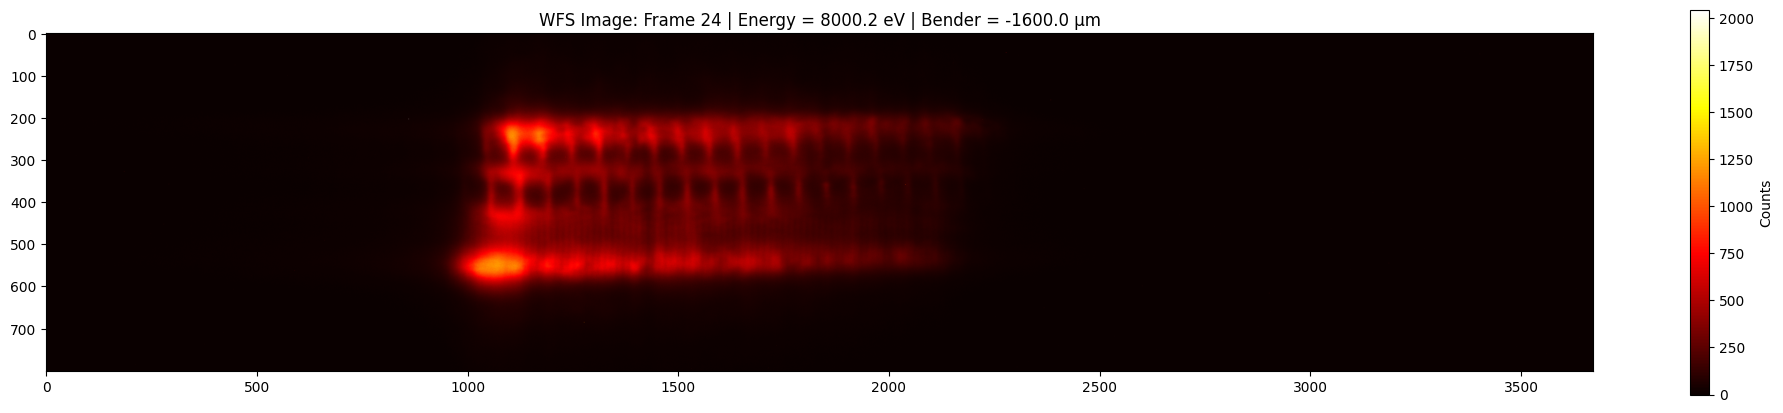

In [6]:
# Quick visualization of one image
idx = 24

plt.figure(figsize=(20, 8))
plt.imshow(images[idx].T, cmap='hot')
plt.title(f'WFS Image: Frame {idx} | Energy = {energy_eV[idx]:.1f} eV | Bender = {bender_um[idx]:.1f} µm')
plt.colorbar(label='Counts', shrink=0.5)
plt.tight_layout()
plt.show()

# ANALYSIS

## Single File 

Phase recon for image `idx=24`. 


In [7]:
# --- Physical parameters ---
z_T             = 0.3                              # Grating-to-detector distance [m]
grating_pitch_m = 7e-6                             # Grating pitch from fabrication [m]
dx_m            = effective_pixel_size_um * 1e-6   # Effective pixel size [m]
wavelength_m    = 1.24e-6 / energy_eV[idx]         # X-ray wavelength [m]

print(f"z_T:             {z_T*1e3:.0f} mm")
print(f"Grating pitch:   {grating_pitch_m*1e6:.1f} µm")
print(f"Pixel size:      {dx_m*1e6:.3f} µm")
print(f"Wavelength:      {wavelength_m*1e9:.4f} nm  ({energy_eV[idx]:.1f} eV)")

z_T:             300 mm
Grating pitch:   7.0 µm
Pixel size:      0.480 µm
Wavelength:      0.1550 nm  (8000.2 eV)


### Data extraction


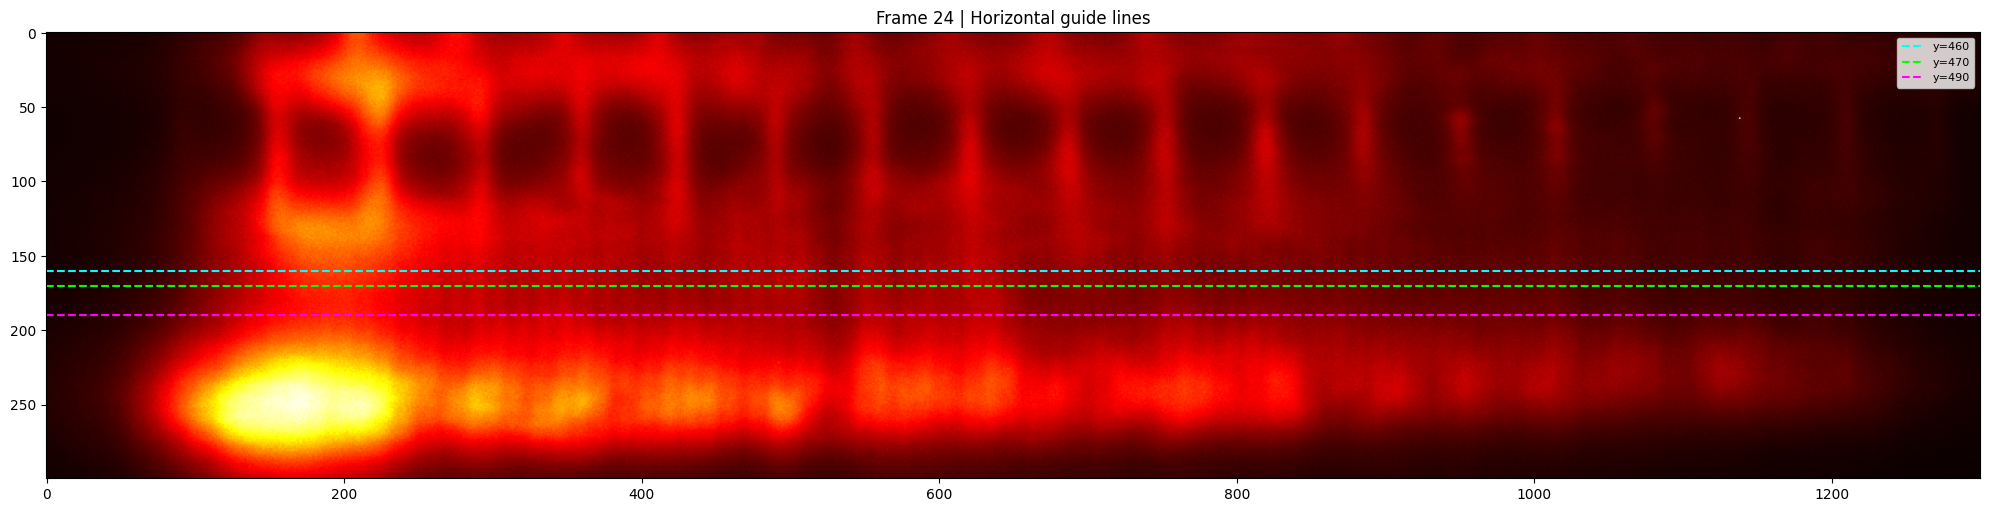

In [8]:
idx = 24
y_sub = 300   # pixels cropped from top for display

fig, ax = plt.subplots(figsize=(20, 5))
ax.imshow(images[idx].T[y_sub:600, 900:2200], cmap='hot')

for y, color in zip([460, 470, 490], ['cyan', 'lime', 'magenta']):
    ax.axhline(y - y_sub, color=color, linewidth=1.5, linestyle='--', label=f'y={y}')

ax.set_title(f'Frame {idx} | Horizontal guide lines')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

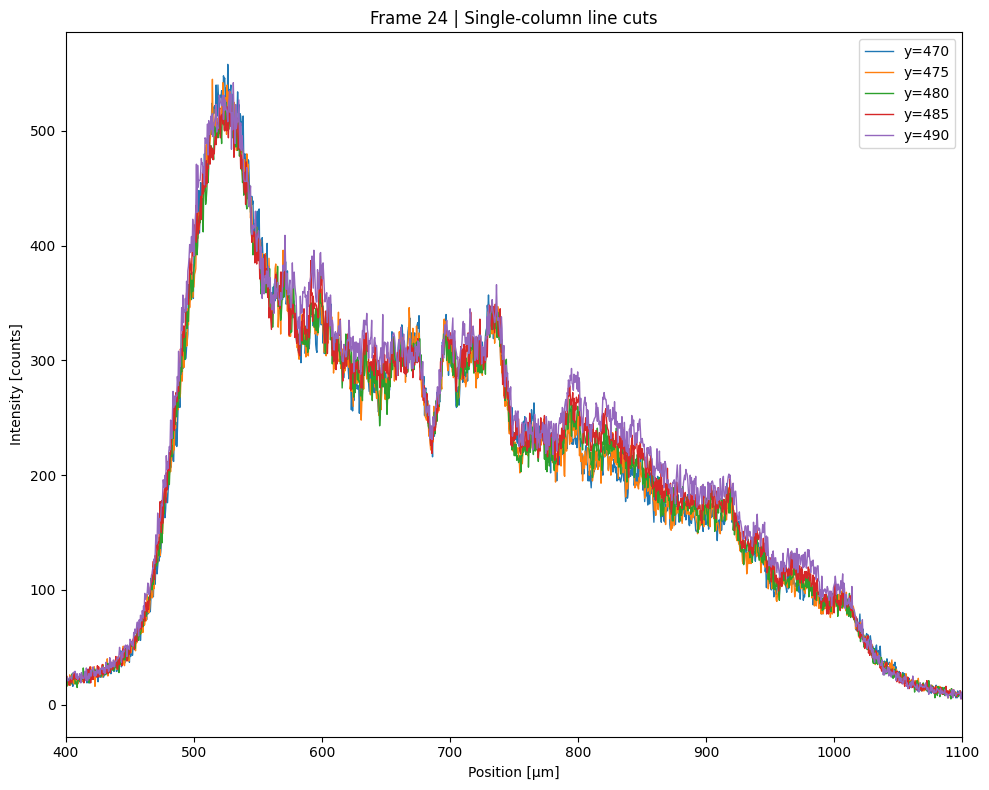

In [9]:
y_cuts = [470, 475, 480, 485, 490]#, 465, 495]

fig, ax = plt.subplots(figsize=(10, 8))
for y in y_cuts:
    profile = images[idx][:, y]
    x_m = np.arange(len(profile)) * dx_m
    if y in [465, 495]:
        ax.plot(x_m * 1e6, profile, linewidth=1, alpha = 0.5, linestyle='--', label=f'y={y}')
    else:
        ax.plot(x_m * 1e6, profile, linewidth=1, label=f'y={y}')

ax.set_xlabel('Position [µm]')
ax.set_ylabel('Intensity [counts]')
ax.set_xlim(400, 1100)
ax.legend(fontsize=10)
ax.set_title(f'Frame {idx} | Single-column line cuts')
plt.tight_layout()
plt.show()

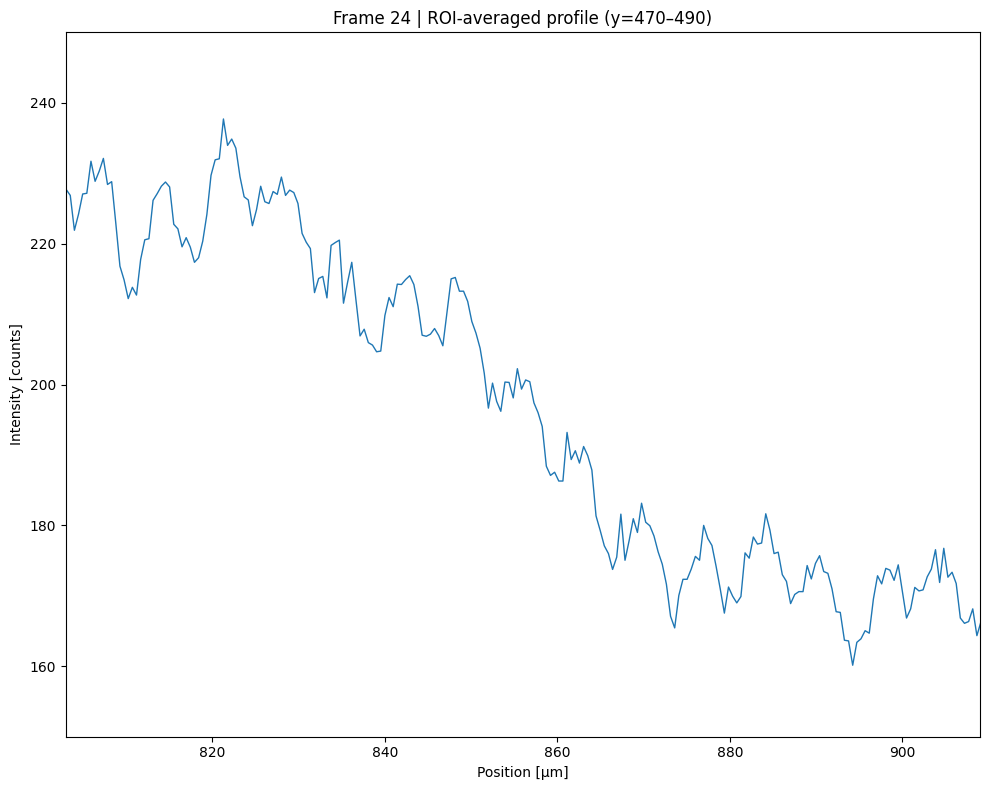

In [10]:
# Plot the 1D profile averaged over the fringe band (y=470–490)

# ROI definition 
x_roi = slice(None)          # full horizontal extent for now
y_roi = slice(470, 490)      # fringe band, confirmed from line cuts above
# y_roi = slice(475, 485)      # fringe band, confirmed from line cuts above --- IGNORE ---

roi = images[idx][:, y_roi]                  # shape: (n_x, 20)
line_profile = np.mean(roi, axis=1)          # average over y → 1D
x_m = np.arange(len(line_profile)) * dx_m

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(x_m * 1e6, line_profile, linewidth=1)
ax.set_xlabel('Position [µm]')
ax.set_ylabel('Intensity [counts]')
# ax.set_xlim(400, 1100)
ax.set_xlim(803, 909)
ax.set_ylim(150, 250)
ax.set_title(f'Frame {idx} | ROI-averaged profile (y=470–490)')
plt.tight_layout()
plt.show()

### Phase reconstruction


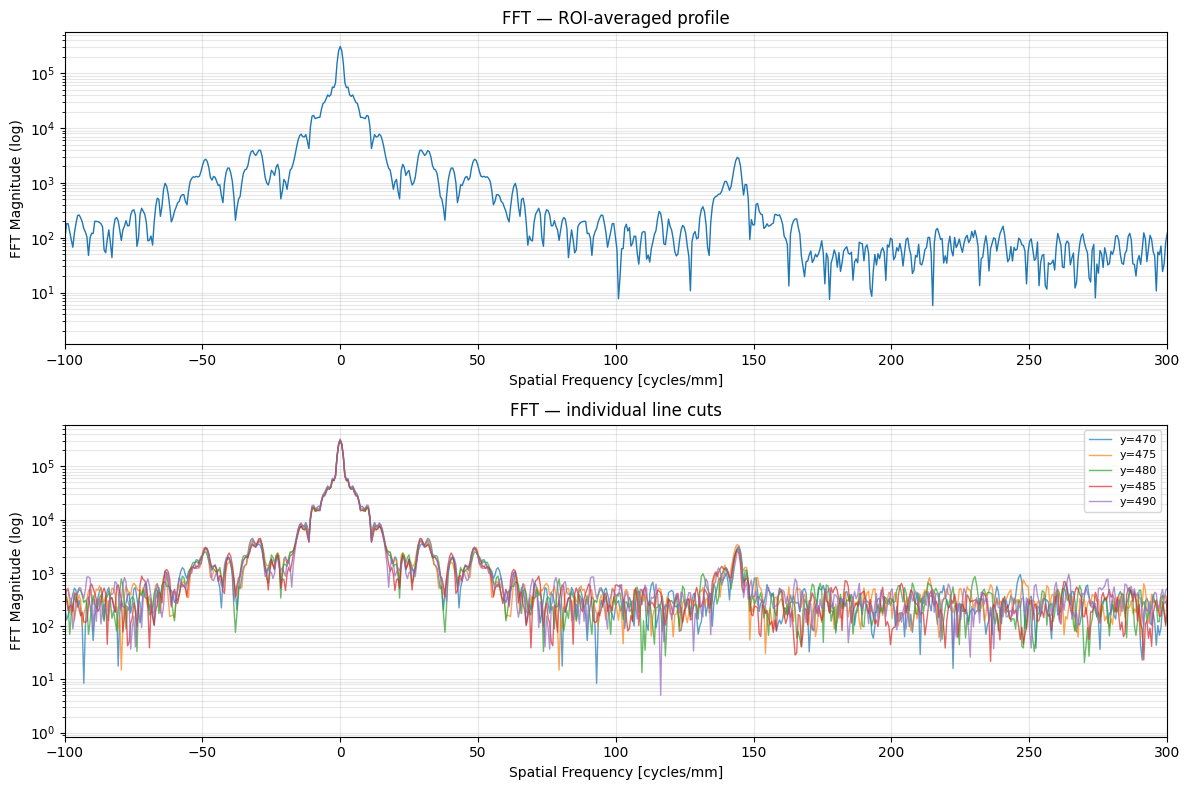

In [11]:
# Trim to beam region to reduce edge noise in FFT
# x_beam = slice(900, 2200)   # pixel range covering ~450–1100 µm
x_beam = slice(0, len(line_profile))   # full range 

# For individual line cuts (same x range)
y_cuts = [470, 475, 480, 485, 490]
profiles = {y: images[idx][x_beam, y] for y in y_cuts}
line_beam = line_profile[x_beam]

# FFT
fft_avg = np.fft.fftshift(np.fft.fft(line_beam))
freq    = np.fft.fftshift(np.fft.fftfreq(len(line_beam), dx_m))

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

ax = axes[0]
ax.semilogy(freq * 1e-3, np.abs(fft_avg), linewidth=1)
ax.set_xlabel('Spatial Frequency [cycles/mm]')
ax.set_ylabel('FFT Magnitude (log)')
ax.set_title('FFT — ROI-averaged profile')
ax.set_xlim(-100, 300)
ax.grid(True, alpha=0.3, which='both')

ax = axes[1]
for y, prof in profiles.items():
    fft_y = np.fft.fftshift(np.fft.fft(prof))
    ax.semilogy(freq * 1e-3, np.abs(fft_y), linewidth=1, alpha=0.7, label=f'y={y}')
ax.set_xlabel('Spatial Frequency [cycles/mm]')
ax.set_ylabel('FFT Magnitude (log)')
ax.set_title('FFT — individual line cuts')
ax.set_xlim(-100, 300)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

Measured carrier: 144.11 cycles/mm
Ideal carrier:    142.86 cycles/mm
Ratio:            1.0088


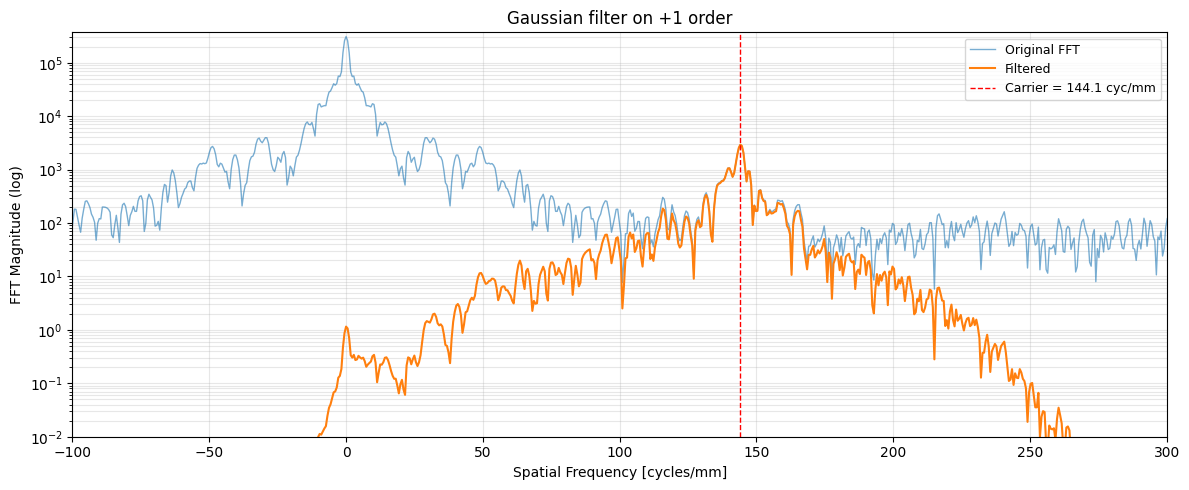

In [12]:
# --- Carrier detection ---
search_mask = (freq >= 100e3) & (freq <= 200e3)
carrier_idx  = np.argmax(np.abs(fft_avg) * search_mask)
k_carrier    = freq[carrier_idx]

print(f"Measured carrier: {k_carrier*1e-3:.2f} cycles/mm")
print(f"Ideal carrier:    {1/grating_pitch_m*1e-3:.2f} cycles/mm")
print(f"Ratio:            {k_carrier/(1/grating_pitch_m):.4f}")

# --- Gaussian filter centered on +1 order ---
filter_sigma  = k_carrier / 5.0   # filter width ~ carrier/5
gauss_filter  = np.exp(-0.5 * ((freq - k_carrier) / filter_sigma)**2)
fft_filtered  = fft_avg * gauss_filter

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(freq * 1e-3, np.abs(fft_avg),      linewidth=1,   alpha=0.6, label='Original FFT')
ax.semilogy(freq * 1e-3, np.abs(fft_filtered),  linewidth=1.5, label='Filtered')
ax.axvline(k_carrier * 1e-3, color='red', linestyle='--', linewidth=1, label=f'Carrier = {k_carrier*1e-3:.1f} cyc/mm')
ax.set_xlabel('Spatial Frequency [cycles/mm]')
ax.set_ylabel('FFT Magnitude (log)')
ax.set_title('Gaussian filter on +1 order')
ax.set_xlim(-100, 300)
ax.set_ylim(1e-2, np.abs(fft_avg).max()*1.2)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

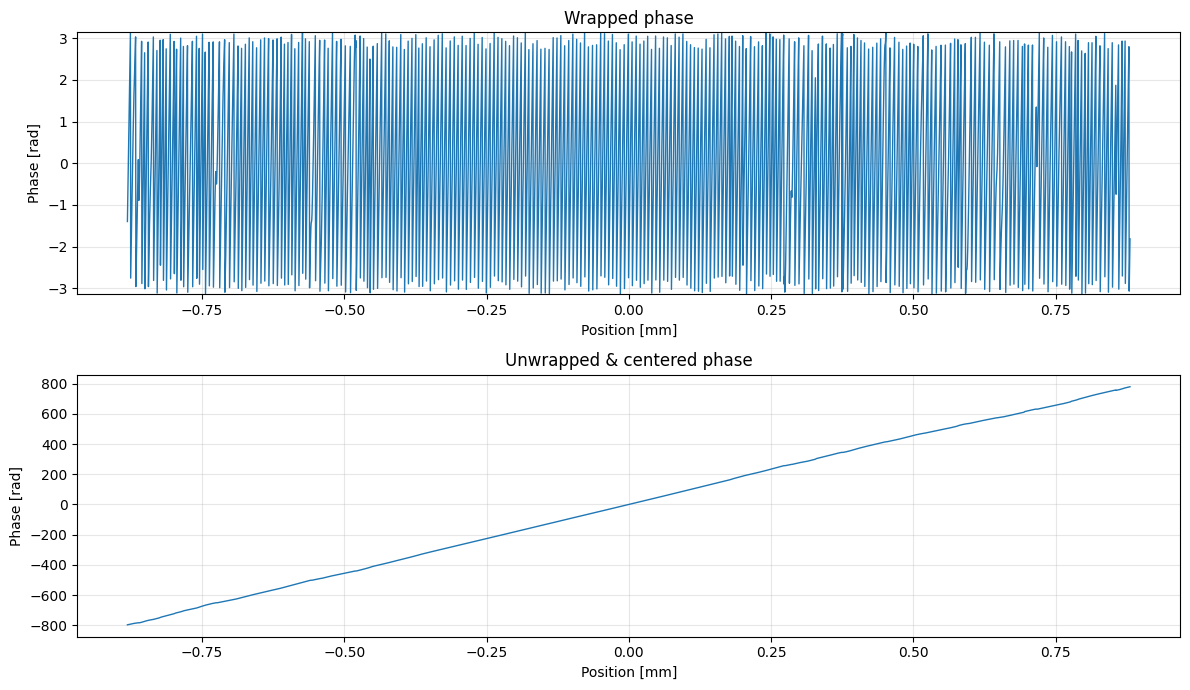

In [13]:
# IFFT of filtered spectrum → complex field
complex_field   = np.fft.ifft(np.fft.ifftshift(fft_filtered))

# Wrapped phase
phase_wrapped   = np.angle(complex_field)

# Unwrap and center at midpoint
phase_unwrapped = np.unwrap(phase_wrapped)
phase_centered  = phase_unwrapped - phase_unwrapped[len(phase_unwrapped)//2]

# Spatial coordinates
x_m = np.arange(len(line_beam)) * dx_m
x_m = x_m - x_m[len(x_m)//2]   # center at 0

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

ax = axes[0]
ax.plot(x_m * 1e3, phase_wrapped, linewidth=1)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Phase [rad]')
ax.set_title('Wrapped phase')
ax.set_ylim(-np.pi, np.pi)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_m * 1e3, phase_centered, linewidth=1)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Phase [rad]')
ax.set_title('Unwrapped & centered phase')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

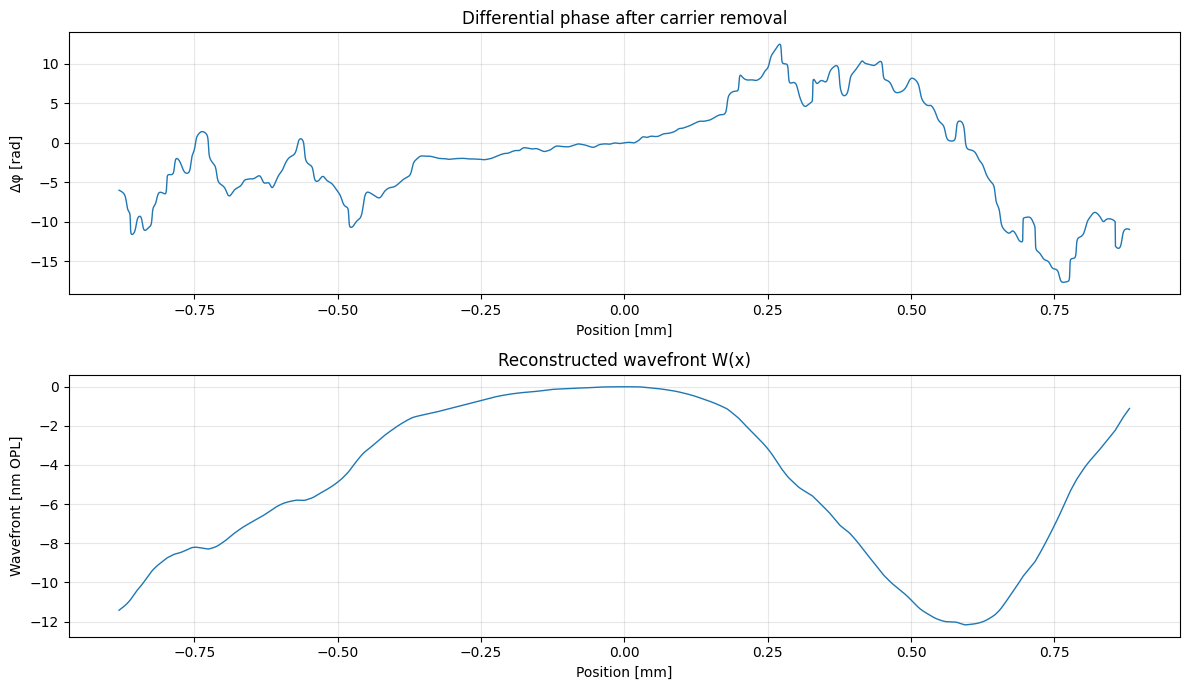

Wavefront PV:  12.17 nm
Wavefront RMS: 4.02 nm


In [14]:
# --- Carrier removal (ideal pitch) ---
carrier_ramp    = 2 * np.pi / grating_pitch_m * x_m
carrier_ramp    = carrier_ramp - carrier_ramp[len(carrier_ramp)//2]
delta_phi       = phase_centered - carrier_ramp

# --- Integration ---
W_temp          = -np.cumsum(delta_phi) * dx_m * grating_pitch_m / wavelength_m / z_T
wavefront_rad   = W_temp - W_temp[len(W_temp)//2]
wavefront_nm    = wavefront_rad * wavelength_m / (2 * np.pi) * 1e9

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

ax = axes[0]
ax.plot(x_m * 1e3, delta_phi, linewidth=1)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Δφ [rad]')
ax.set_title('Differential phase after carrier removal')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_m * 1e3, wavefront_nm, linewidth=1)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Wavefront [nm OPL]')
ax.set_title('Reconstructed wavefront W(x)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Wavefront PV:  {wavefront_nm.max() - wavefront_nm.min():.2f} nm")
print(f"Wavefront RMS: {np.std(wavefront_nm):.2f} nm")

### Improvements

The pipeline above gives a defensible $W(x)$, but two issues remain:

1. **Phase centering uses the array midpoint, not the beam.** Since the beam drifts horizontally with energy, referencing $W(x)$ to a fixed pixel introduces an energy-dependent spurious tilt.
2. **No amplitude profile $\Rightarrow$ no field $\Rightarrow$ no propagation.** To find the focus we need $E(x) = A(x)\,\exp[i W(x)]$, not just $W(x)$.

Both are solved by extracting the **0th-order envelope** $I_0(x)$ from the same FFT we already use: it gives the beam centroid $x_c$ for phase reference (fix #1) and the amplitude $A(x) = \sqrt{I_0(x)}$ for field construction (fix #2).

We work through it on idx = 22 (strongly over-bent, 8000 eV) below, then apply the consolidated pipeline to idx = 24 in §4.

#### 1. Envelope extraction and centroid

We extract two envelopes from the same FFT of the line profile:
- **0th order** (low-pass at $f = 0$) → beam intensity $I_0(x)$
- **+1 order** (bandpass at $f = k_c$) → fringe amplitude $|A_{+1}(x)| \propto I_0(x)\,V(x)$

Filter width choice is constrained by sideband leakage (too wide) vs. over-smoothing (too narrow). The next two cells verify filter width sensitivity; the third commits to locked-in choices and produces final envelopes plus visibility $V(x)$.

Predicted carrier (1/p)        : k_c    = 142.86 cyc/mm
Measured +1-order FFT peak     : k_peak = 148.08 cyc/mm


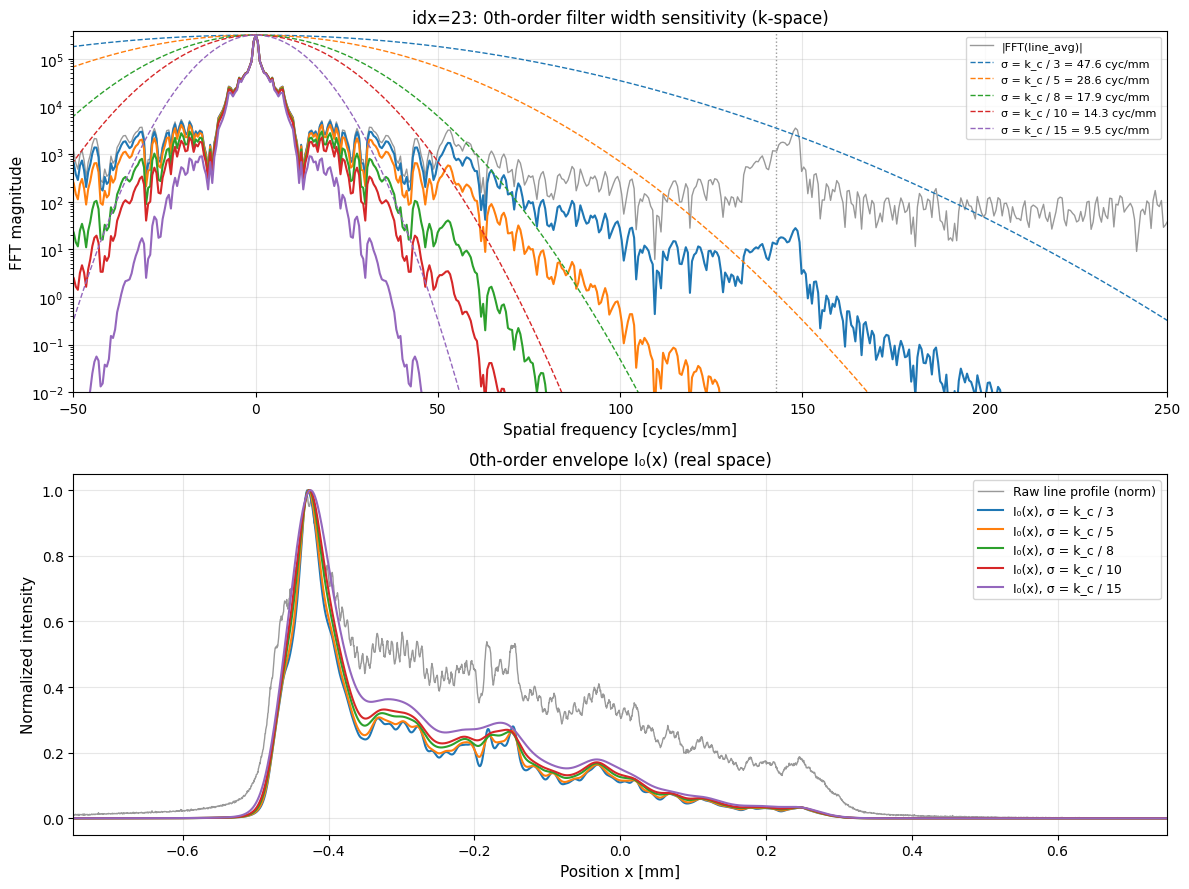

In [39]:
# 0th-order filter width sensitivity 
# Show k-space filters + filtered FFTs and resulting I_0(x).

idx = 23
line_avg = np.mean(images[idx][:, y_roi], axis=1)
N        = len(line_avg)
freq     = np.fft.fftshift(np.fft.fftfreq(N, dx_m))
fft_avg  = np.fft.fftshift(np.fft.fft(line_avg))
x_m      = (np.arange(N) - N // 2) * dx_m

# Predicted carrier from grating pitch (used later for the 2π/p ramp subtraction)
k_c = 2 * np.pi / grating_pitch_m / (2 * np.pi)   # = 1/p, in cyc/m

# Measured +1-order peak location (used to center the Gaussian bandpass filter)
search_mask = (freq >= 120e3) & (freq <= 180e3)
k_peak      = freq[np.argmax(np.abs(fft_avg) * search_mask)]

print(f"Predicted carrier (1/p)        : k_c    = {k_c   *1e-3:.2f} cyc/mm")
print(f"Measured +1-order FFT peak     : k_peak = {k_peak*1e-3:.2f} cyc/mm")

raw_scaled = line_avg / np.max(line_avg)
peak_amp   = np.max(np.abs(fft_avg))

sigma_ratios_0th = [3, 5, 8, 10, 15]
colors_0th       = ['C0', 'C1', 'C2', 'C3', 'C4']
I0_dict          = {}

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Top: k-space — filters (dashed) and filtered FFTs (solid)
ax = axes[0]
ax.plot(freq * 1e-3, np.abs(fft_avg), 'gray', lw=1, alpha=0.8, label='|FFT(line_avg)|')
ax.axvline( k_c * 1e-3, color='gray', ls=':', lw=1, alpha=0.8)
ax.axvline(-k_c * 1e-3, color='gray', ls=':', lw=1, alpha=0.8)

for r, c in zip(sigma_ratios_0th, colors_0th):
    sig          = k_c / r
    gauss_lp     = np.exp(-0.5 * (freq / sig)**2)
    fft_filt_0   = fft_avg * gauss_lp
    I0_dict[r]   = np.abs(np.fft.ifft(np.fft.ifftshift(fft_filt_0)))**2
    ax.plot(freq * 1e-3, gauss_lp * peak_amp, color=c, lw=1, ls='--',
            label=f'σ = k_c / {r} = {sig*1e-3:.1f} cyc/mm')
    ax.plot(freq * 1e-3, np.abs(fft_filt_0), color=c, lw=1.5)

ax.set_xlabel('Spatial frequency [cycles/mm]', fontsize=11)
ax.set_ylabel('FFT magnitude', fontsize=11)
ax.set_title(f'idx={idx}: 0th-order filter width sensitivity (k-space)', fontsize=12)
ax.set_xlim(-50, 250)
ax.set_ylim(1e-2, peak_amp * 1.2)
ax.set_yscale('log')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

# Bottom: real-space — normalized I_0(x) for each σ
ax = axes[1]
ax.plot(x_m * 1e3, raw_scaled, color='gray', lw=1, alpha=0.8, label='Raw line profile (norm)')
for r, c in zip(sigma_ratios_0th, colors_0th):
    I0_norm_r = I0_dict[r] / np.max(I0_dict[r])
    ax.plot(x_m * 1e3, I0_norm_r, color=c, lw=1.5, label=f'I₀(x), σ = k_c / {r}')

ax.set_xlabel('Position x [mm]', fontsize=11)
ax.set_ylabel('Normalized intensity', fontsize=11)
ax.set_title('0th-order envelope I₀(x) (real space)', fontsize=12)
ax.set_xlim(-.75, .75)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

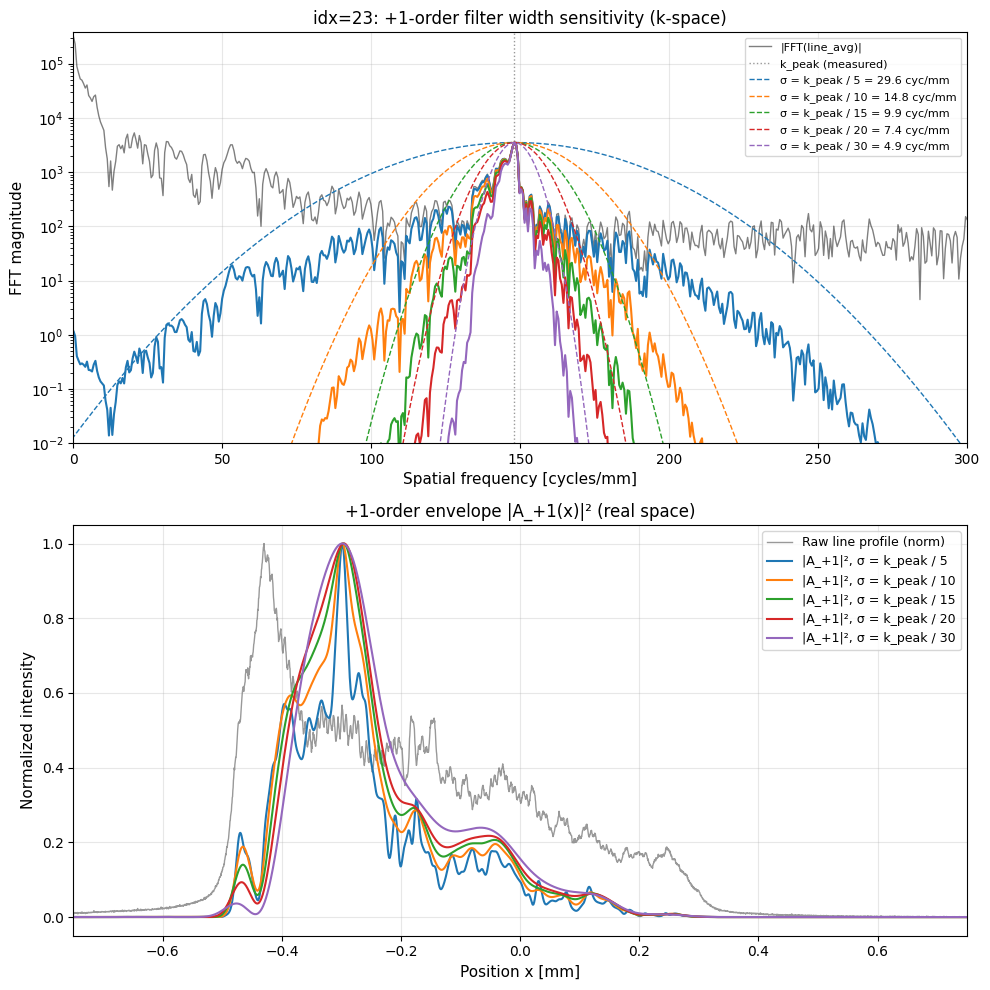

In [43]:
# --- +1-order filter width sensitivity ---
# Five σ candidates; show k-space filters + filtered FFTs and resulting |A_+1|²(x).

sigma_ratios_1st = [5, 10, 15, 20, 30]
colors_1st       = ['C0', 'C1', 'C2', 'C3', 'C4']
A1_dict          = {}

# Rescale dashed Gaussian envelopes to the FFT amplitude AT the +1-order peak,
# not at DC (the global peak), so they're visually meaningful at +1 order.
kpeak_index = np.argmin(np.abs(freq - k_peak))
peak_at_kpeak = np.abs(fft_avg[kpeak_index])

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Top: k-space
ax = axes[0]
ax.plot(freq * 1e-3, np.abs(fft_avg), 'k', lw=1, alpha=0.5, label='|FFT(line_avg)|')
ax.axvline(k_peak * 1e-3, color='gray', ls=':', lw=1, alpha=0.8, label='k_peak (measured)')

for r, c in zip(sigma_ratios_1st, colors_1st):
    sig            = k_peak / r
    gauss_bp       = np.exp(-0.5 * ((freq - k_peak) / sig)**2)
    fft_filt_1     = fft_avg * gauss_bp
    A1_dict[r]     = np.abs(np.fft.ifft(np.fft.ifftshift(fft_filt_1)))
    ax.plot(freq * 1e-3, gauss_bp * peak_at_kpeak, color=c, lw=1, ls='--',
            label=f'σ = k_peak / {r} = {sig*1e-3:.1f} cyc/mm')
    ax.plot(freq * 1e-3, np.abs(fft_filt_1), color=c, lw=1.5)

ax.set_xlabel('Spatial frequency [cycles/mm]', fontsize=11)
ax.set_ylabel('FFT magnitude', fontsize=11)
ax.set_title(f'idx={idx}: +1-order filter width sensitivity (k-space)', fontsize=12)
ax.set_xlim(0, 300)
ax.set_ylim(1e-2, peak_amp * 1.2)
ax.set_yscale('log')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

# Bottom: real-space — normalized |A_+1|² for each σ
ax = axes[1]
ax.plot(x_m * 1e3, raw_scaled, color='gray', lw=1, alpha=0.8, label='Raw line profile (norm)')
for r, c in zip(sigma_ratios_1st, colors_1st):
    A1_sq      = A1_dict[r]**2
    A1_sq_norm = A1_sq / np.max(A1_sq)
    ax.plot(x_m * 1e3, A1_sq_norm, color=c, lw=1.5, label=f'|A_+1|², σ = k_peak / {r}')

ax.set_xlabel('Position x [mm]', fontsize=11)
ax.set_ylabel('Normalized intensity', fontsize=11)
ax.set_title('+1-order envelope |A_+1(x)|² (real space)', fontsize=12)
ax.set_xlim(-.75, .75)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

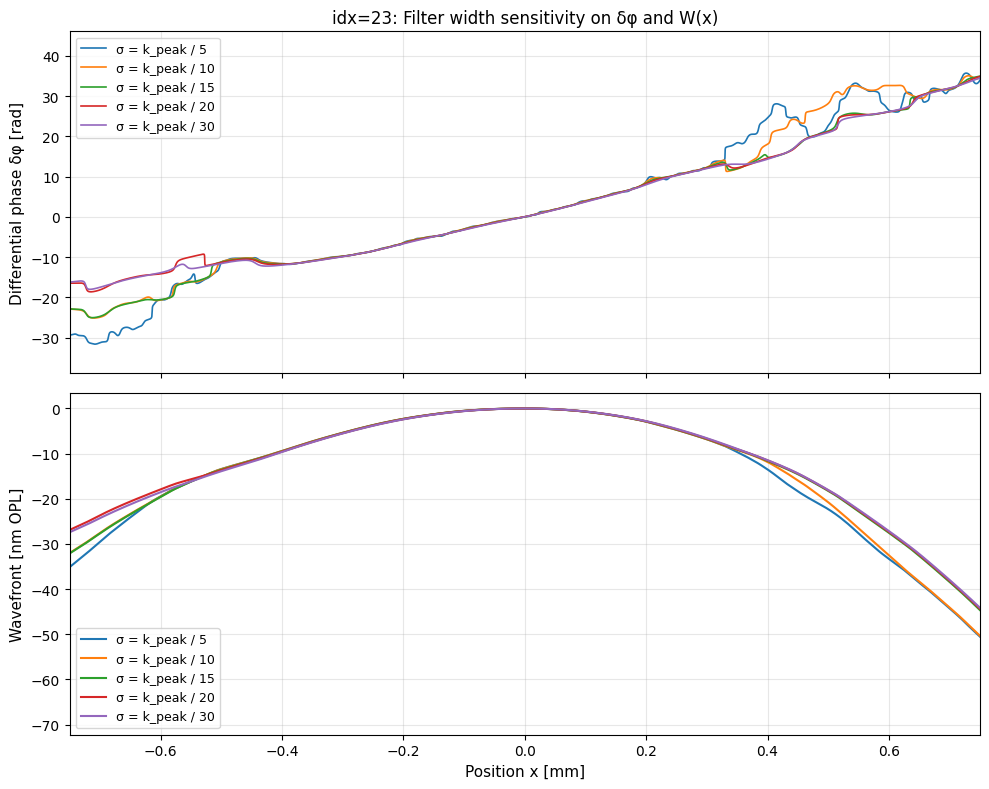

W(x) RMS difference vs. σ = k_peak/10 (over beam region):
  σ = k_peak/5  : RMS = 0.007 nm,  PV = 0.047 nm
  σ = k_peak/15 : RMS = 0.047 nm,  PV = 0.193 nm
  σ = k_peak/20 : RMS = 0.090 nm,  PV = 0.375 nm
  σ = k_peak/30 : RMS = 0.155 nm,  PV = 0.684 nm


In [47]:
# +1-order filter: does σ choice affect W(x)? 
# Quick check before committing: reconstruct W(x) for σ = k_peak/5, /10, /15, /20, /30.
# Note: filter is centered at k_peak (measured FFT peak),
# but the carrier ramp subtraction uses predicted 2π/p from the grating pitch.

sigma_test = [5, 10, 15, 20, 30]
W_test     = {}

for r in sigma_test:
    sig            = k_peak / r
    gauss          = np.exp(-0.5 * ((freq - k_peak) / sig)**2)
    fft_filtered   = fft_avg * gauss
    complex_1st_r  = np.fft.ifft(np.fft.ifftshift(fft_filtered))

    phase_unwrapped = np.unwrap(np.angle(complex_1st_r))
    phase_centered  = phase_unwrapped - phase_unwrapped[N // 2]

    carrier_ramp  = 2 * np.pi / grating_pitch_m * x_m
    carrier_ramp  = carrier_ramp - carrier_ramp[N // 2]
    delta_phi     = phase_centered - carrier_ramp

    W_temp        = -np.cumsum(delta_phi) * dx_m * grating_pitch_m / wavelength_m / z_T
    W_rad         = W_temp - W_temp[N // 2]
    W_nm          = W_rad * wavelength_m / (2 * np.pi) * 1e9
    W_test[r]     = dict(W_nm=W_nm, delta_phi=delta_phi,
                         A=np.abs(complex_1st_r))

# --- Plot: δφ and W(x) overlays ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
for r, c in zip(sigma_test, colors_1st):
    A_norm = W_test[r]['A'] / np.max(W_test[r]['A'])
    dphi   = W_test[r]['delta_phi'].copy()
    # dphi[A_norm < 0.05] = np.nan
    ax.plot(x_m * 1e3, dphi, color=c, lw=1.2, label=f'σ = k_peak / {r}')
ax.set_xlim(-1, 1) 
ax.set_ylabel('Differential phase δφ [rad]', fontsize=11)
ax.set_title(f'idx={idx}: Filter width sensitivity on δφ and W(x)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
for r, c in zip(sigma_test, colors_1st):
    ax.plot(x_m * 1e3, W_test[r]['W_nm'], color=c, lw=1.5, label=f'σ = k_peak / {r}')
ax.set_xlabel('Position x [mm]', fontsize=11)
ax.set_ylabel('Wavefront [nm OPL]', fontsize=11)
ax.set_xlim(-.75, .75)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantify W(x) sensitivity to σ choice (over the beam region)
beam_mask_W = (W_test[10]['A'] > 0.05 * np.max(W_test[10]['A']))
print("W(x) RMS difference vs. σ = k_peak/10 (over beam region):")
for r in sigma_test:
    if r == 10:
        continue
    diff = W_test[r]['W_nm'] - W_test[10]['W_nm']
    print(f"  σ = k_peak/{r:<3}: RMS = {np.std(diff[beam_mask_W]):.3f} nm,  "
          f"PV = {np.ptp(diff[beam_mask_W]):.3f} nm")

**Filter widths committed:**

| Filter | Center | σ in k-space | Driving constraint |
|--------|--------|--------------|--------------------|
| 0th order | $f = 0$ | $k_\text{peak} / 5$ | Wide enough for beam content; narrow enough to suppress ±$k_\text{peak}$ sideband leakage |
| +1 order | $f = k_\text{peak}$ | $k_\text{peak} / 10$ | Matched to sideband width; narrow enough to suppress DC leakage |

$W(x)$ is **insensitive** to σ_+1 within the tested range; see the RMS/PV table printed by the previous cell. We use $k_\text{peak}/10$ for consistency with the F2 grid pipeline.

__Sidenote: $k_\text{peak}$ vs $k_\text{carrier}$.__ 

Filter centering uses $k_\text{peak}$ — the *measured* +1-order FFT peak — because that's where the sideband actually lives (and shifts slightly per frame due to the wavefront). The *predicted* carrier $k_\text{carrier} = 1/p$ (fixed by the grating pitch) is used only for the ramp subtraction in §2 — any deviation of $k_\text{peak}$ from $k_\text{carrier}$ is real wavefront tilt and belongs in $W(x)$.

beam_mask: 862 px raw → 971 px after fill (109 px filled in)


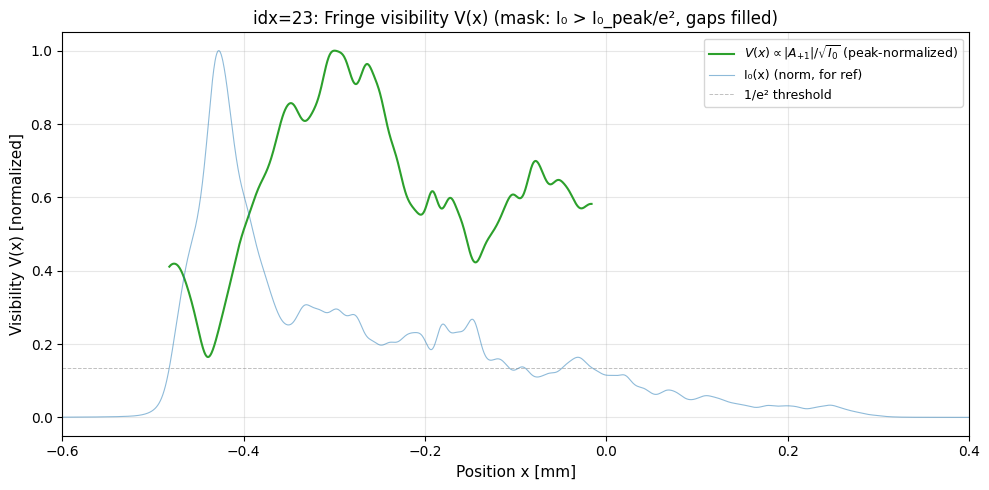

In [138]:
# Final check: how does the visibility V(x) = |A_+1| / sqrt(I_0) look 
sigma_0th = k_peak / 5
sigma_1st = k_peak / 10

# 0th order: low-pass at f = 0
gauss_lp     = np.exp(-0.5 * (freq / sigma_0th)**2)
fft_filt_0   = fft_avg * gauss_lp
complex_0th  = np.fft.ifft(np.fft.ifftshift(fft_filt_0))
I0           = np.abs(complex_0th)**2

# +1 order: bandpass at f = k_peak (measured)
gauss_bp     = np.exp(-0.5 * ((freq - k_peak) / sigma_1st)**2)
fft_filt_1   = fft_avg * gauss_bp
complex_1st  = np.fft.ifft(np.fft.ifftshift(fft_filt_1))
A1           = np.abs(complex_1st)

# Beam mask: I₀ > I₀_peak/e², then fill interior gaps so the mask is contiguous
def fill_mask_gaps(mask):
    """Fill all interior False gaps in a 1D boolean mask."""
    if not mask.any():
        return mask
    idx_true = np.where(mask)[0]
    out = np.zeros_like(mask)
    out[idx_true[0]:idx_true[-1]+1] = True
    return out

beam_mask_raw = I0 > np.exp(-2) * np.max(I0)
beam_mask_V   = fill_mask_gaps(beam_mask_raw)

# Visibility V(x) ∝ |A_+1| / sqrt(I_0), evaluated on the gap-filled mask
V_x            = np.zeros_like(I0)
V_x[beam_mask_V] = A1[beam_mask_V] / np.sqrt(I0[beam_mask_V])
V_x_norm       = V_x / np.max(V_x[beam_mask_V])

# Diagnostic: report what the gap-fill added
n_added = beam_mask_V.sum() - beam_mask_raw.sum()
print(f"beam_mask: {beam_mask_raw.sum()} px raw → {beam_mask_V.sum()} px after fill "
      f"({n_added} px filled in)")

# --- Plot: V(x) overlaid with normalized I_0 for reference ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_m * 1e3, np.where(beam_mask_V, V_x_norm, np.nan), 'C2', lw=1.5,
        label=r'$V(x) \propto |A_{+1}| / \sqrt{I_0}$ (peak-normalized)')
ax.plot(x_m * 1e3, I0 / np.max(I0), 'C0', lw=0.8, alpha=0.5, label='I₀(x) (norm, for ref)')
ax.axhline(np.exp(-2), color='gray', ls='--', lw=0.7, alpha=0.5, label='1/e² threshold')
ax.set_xlabel('Position x [mm]', fontsize=11)
ax.set_ylabel('Visibility V(x) [normalized]', fontsize=11)
ax.set_title(f'idx={idx}: Fringe visibility V(x) (mask: I₀ > I₀_peak/e², gaps filled)', fontsize=12)
ax.set_xlim(-.6, .4)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Phase-reference centroid.** $W(x)$ is reconstructed up to an additive constant, set by the choice of reference point. The current pipeline uses the array midpoint ($N/2$) — a fixed detector pixel — but the beam drifts horizontally with energy, so this introduces a spurious tilt.

The reference should sit in the *measurement region*, where fringes are clean. Three candidates:
- (a) **Peak of $|A_{+1}|$** — too noise-sensitive
- (b) **Geometric center of $\{V(x) > 0.4\}$** — treats all "good" pixels equally
- (c) **Centroid of $|A_{+1}|^2$ under an $I_0$ mask** — each pixel weighted by signal × phase-extraction quality

We go with **option (c)**: each pixel weighted by $I_0 \cdot V^2$ — proportional to signal strength times phase-extraction quality. Sensitivity to the $I_0$ mask threshold is tested below.

Threshold  cutoff          centroid pixel     x [mm]      
------------------------------------------------------------
1e-2       2102.5          pix 1296           -0.2592
0.05       10512.7         pix 1283           -0.2654
1/e²       28454.8         pix 1248           -0.2822


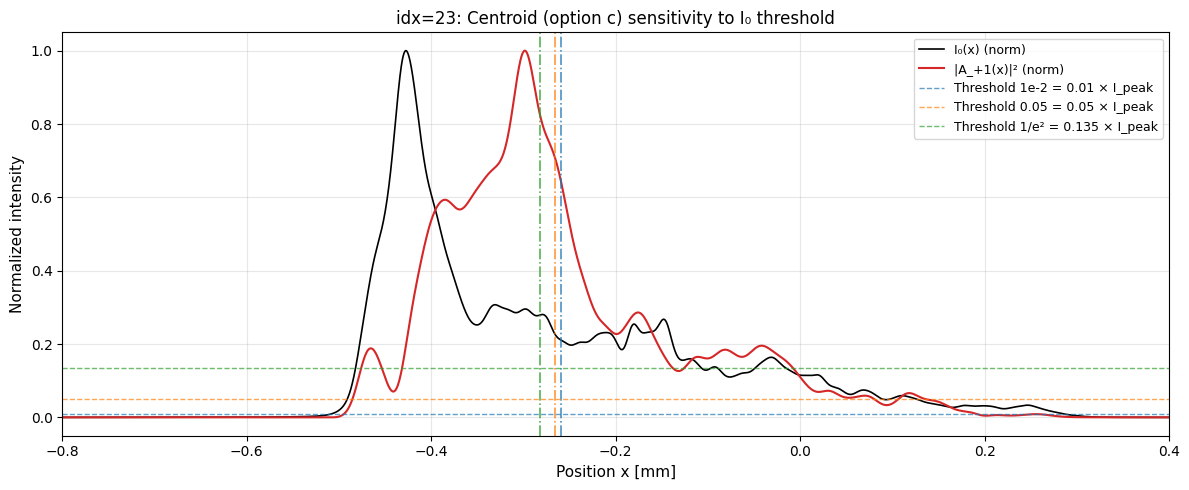

In [139]:
# --- Centroid sensitivity to I0 threshold ---
# Diagnostic: how much does the centroid move with the I0 mask threshold?

x_idx = np.arange(N)

thresholds = {
    '1e-2': 1e-2,
    '0.05': 0.05,
    '1/e²': np.exp(-2),
}
threshold_colors = {'1e-2': 'C0', '0.05': 'C1', '1/e²': 'C2'}

I0_peak = np.max(I0)
I0_norm = I0 / I0_peak
A1_sq_norm = (A1**2) / np.max(A1**2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_m * 1e3, I0_norm,    'k',  lw=1.2, label='I₀(x) (norm)')
ax.plot(x_m * 1e3, A1_sq_norm, 'C3', lw=1.5, label='|A_+1(x)|² (norm)')

print(f"{'Threshold':<10} {'cutoff':<15} {'centroid pixel':<18} {'x [mm]':<12}")
print('-' * 60)

for name, thr in thresholds.items():
    cutoff = thr * I0_peak
    mask_t = fill_mask_gaps(I0 > cutoff)     # gap-filled, consistent with cell 29
    c      = threshold_colors[name]

    x_c_t = int(np.average(x_idx[mask_t], weights=A1[mask_t]**2))

    ax.axhline(thr, color=c, lw=1, ls='--', alpha=0.7,
               label=f'Threshold {name} = {thr:.3g} × I_peak')
    ax.axvline(x_m[x_c_t] * 1e3, color=c, lw=1.2, ls='-.', alpha=0.8)

    print(f"{name:<10} {cutoff:<15.1f} pix {x_c_t:<14} {x_m[x_c_t]*1e3:+.4f}")

ax.set_xlabel('Position x [mm]', fontsize=11)
ax.set_ylabel('Normalized intensity', fontsize=11)
ax.set_title(f'idx={idx}: Centroid (option c) sensitivity to I₀ threshold', fontsize=12)
ax.set_xlim(-.8, .4)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Centroid choice committed.** We use the $1/e^2$ threshold (standard beam-edge convention) with $|A_{+1}|^2$ weighting on the gap-filled mask. The centroid moves by only ~10 pixels across the threshold range tested, so the choice is mild — but $1/e^2$ is principled and consistent with §1's filter-width reasoning.

The numerical value of `x_c_phase` is computed at the start of §2.

#### 2. Wavefront reconstruction with corrected centering

With $\sigma$ values and centroid definition locked in from §1, we now recompute $W(x)$ using `x_c_phase` as the phase reference instead of the array midpoint. Two changes from the original pipeline:

1. `phase_centered = phase_unwrapped - phase_unwrapped[x_c_phase]`
2. `wavefront_rad  = W_temp - W_temp[x_c_phase]`

The carrier ramp subtraction (`carrier_ramp - carrier_ramp[x_c_phase]`) follows the same convention. We then compare the corrected $W(x)$ against the original midpoint-centered reconstruction.

In [140]:
# Corrected reconstruction with x_c_phase as phase reference

# Compute centroid (option c, 1/e² mask, gap-filled), per §1 conclusion
x_c_phase = int(np.average(np.arange(N)[beam_mask_V], weights=A1[beam_mask_V]**2))

print(f"Phase reference centroid: pixel {x_c_phase}, x = {x_m[x_c_phase]*1e3:+.4f} mm")

# Reconstruction with corrected centering
# Filter centered at k_peak (measured); carrier ramp uses 2π/p (predicted)
phase_unwrapped = np.unwrap(np.angle(complex_1st))
phase_centered  = phase_unwrapped - phase_unwrapped[x_c_phase]

carrier_ramp    = 2 * np.pi / grating_pitch_m * x_m
carrier_ramp    = carrier_ramp - carrier_ramp[x_c_phase]
delta_phi       = phase_centered - carrier_ramp

W_temp          = -np.cumsum(delta_phi) * dx_m * grating_pitch_m / wavelength_m / z_T
wavefront_rad   = W_temp - W_temp[x_c_phase]
wavefront_nm    = wavefront_rad * wavelength_m / (2 * np.pi) * 1e9

Phase reference centroid: pixel 1248, x = -0.2822 mm


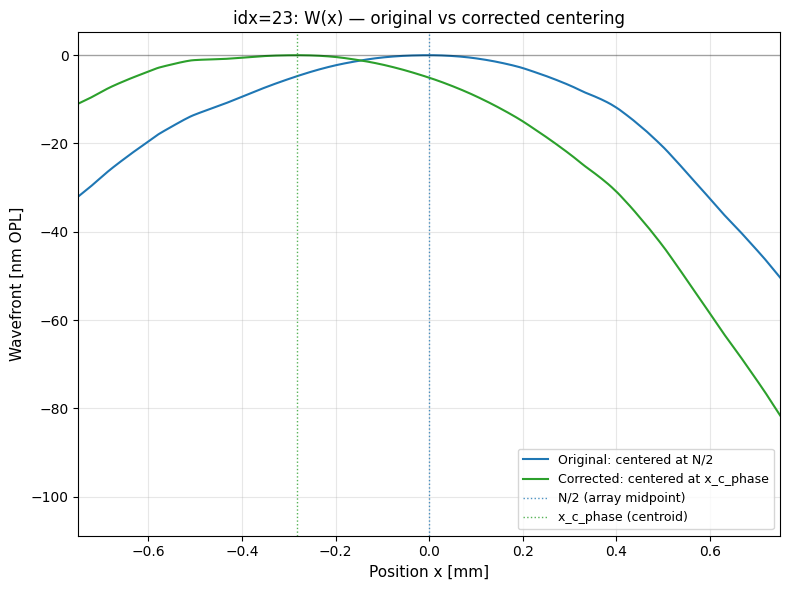

W_corrected − W_original over beam region (mask: I₀ > I₀_peak/e², gap-filled):
  range = [-4.5216, +11.7012] nm
  PV    = 16.2228 nm
  RMS   = 4.6879 nm


In [141]:
# Compare corrected vs original (midpoint-centered) reconstruction

# Reconstruct the old version (midpoint-centered) for direct comparison
phase_centered_old = phase_unwrapped - phase_unwrapped[N // 2]
carrier_ramp_old   = 2 * np.pi / grating_pitch_m * x_m
carrier_ramp_old   = carrier_ramp_old - carrier_ramp_old[N // 2]
delta_phi_old      = phase_centered_old - carrier_ramp_old
W_temp_old         = -np.cumsum(delta_phi_old) * dx_m * grating_pitch_m / wavelength_m / z_T
W_rad_old          = W_temp_old - W_temp_old[N // 2]
W_nm_old           = W_rad_old * wavelength_m / (2 * np.pi) * 1e9

# --- Plot: old vs new W(x), with reference markers ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_m * 1e3, W_nm_old,     'C0', lw=1.5, label='Original: centered at N/2')
ax.plot(x_m * 1e3, wavefront_nm, 'C2', lw=1.5, label='Corrected: centered at x_c_phase')
ax.axvline(x_m[N//2] * 1e3,       color='C0', ls=':', lw=1, alpha=0.8, label='N/2 (array midpoint)')
ax.axvline(x_m[x_c_phase] * 1e3, color='C2', ls=':', lw=1, alpha=0.8, label='x_c_phase (centroid)')
ax.axhline(0, color='k', lw=1, alpha=0.3)

ax.set_xlabel('Position x [mm]', fontsize=11)
ax.set_ylabel('Wavefront [nm OPL]', fontsize=11)
ax.set_title(f'idx={idx}: W(x) — original vs corrected centering', fontsize=12)
ax.set_xlim(-.75, .75)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quantify the tilt that was removed (over the beam region)
W_diff = wavefront_nm - W_nm_old
print(f"W_corrected − W_original over beam region (mask: I₀ > I₀_peak/e², gap-filled):")
print(f"  range = [{np.min(W_diff[beam_mask_V]):+.4f}, {np.max(W_diff[beam_mask_V]):+.4f}] nm")
print(f"  PV    = {np.ptp(W_diff[beam_mask_V]):.4f} nm")
print(f"  RMS   = {np.std(W_diff[beam_mask_V]):.4f} nm")


**Observations:** The two curves differ by a linear tilt — the expected effect of shifting the phase reference. The corrected $W(x)$ passes through zero at $x_c$ by construction; the original passes through zero at $N/2$. The tilt magnitude (PV / RMS over the beam region) is printed above.

`wavefront_nm` and `wavefront_rad` are now the corrected versions, ready for §3.

#### 3. Field construction and Fresnel propagation

Construct $E_\text{det}(x) = A(x)\,\exp[i W(x)]$ at the detector plane and propagate over a range of $z$ using `monoplus.propTF`. Find the focus from the RMS beam width $\sigma_\text{rms}(z)$ (second moment), with an independent cross-check from a parabolic fit to $W(x)$: for a converging wave $W = -kx^2/(2f)$, so $f_\text{pred} = -k/(2 a_2)$.

The amplitude is **V-apodized**: $A(x) = \sqrt{I_0(x)}\,V(x)$ inside the beam mask, zero outside. The apodization suppresses edge-diffraction artifacts that otherwise dominate $\sigma_\text{rms}(z)$ and prevent focus detection.

Propagation: z_focus = +8.600 m, σ_rms at focus = 30.42 µm


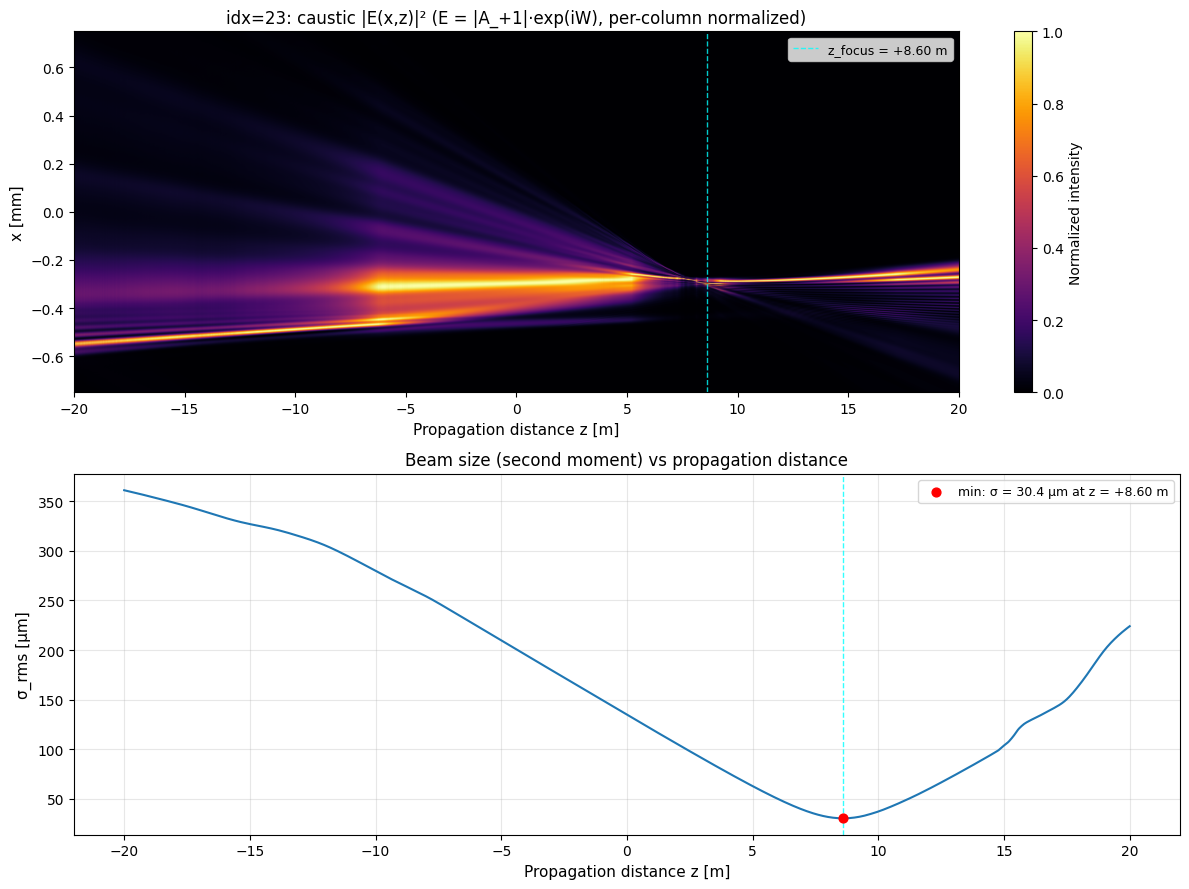

In [151]:
# --- V-apodized propagation (Use |A_+1| directly, no masking) ---
# |A_+1(x)| = √I₀(x)·V(x) by construction. Using it as amplitude tapers
# naturally to ~0 in the no-fringe region without any threshold.

E_det = A1 * np.exp(1j * wavefront_rad)

L_m       = N * dx_m
z_range_m = np.linspace(-20.0, 20.0, 801)
Z         = len(z_range_m)

E_caustic = np.zeros((N, Z), dtype=complex)
for i_z, z in enumerate(z_range_m):
    E_caustic[:, i_z] = mp.propTF(E_det, L_m, wavelength_m, z)
I_caustic = np.abs(E_caustic)**2
sigma_rms = mp.secondmomt(Z, x_m, E_caustic)

i_focus     = np.argmin(sigma_rms)
z_focus     = z_range_m[i_focus]
sigma_focus = sigma_rms[i_focus]

print(f"Propagation: z_focus = {z_focus:+.3f} m, σ_rms at focus = {sigma_focus*1e6:.2f} µm")

# --- Plot: caustic + σ_rms(z) ---
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

ax = axes[0]
I_caustic_norm = I_caustic / np.max(I_caustic, axis=0, keepdims=True)
im = ax.imshow(I_caustic_norm,
               extent=(z_range_m[0], z_range_m[-1], x_m[0]*1e3, x_m[-1]*1e3),
               aspect='auto', origin='lower', cmap='inferno')
ax.axvline(z_focus, color='cyan', lw=1, ls='--', alpha=0.8, label=f'z_focus = {z_focus:+.2f} m')
ax.set_xlabel('Propagation distance z [m]', fontsize=11)
ax.set_ylabel('x [mm]', fontsize=11)
ax.set_title(f'idx={idx}: caustic |E(x,z)|² (E = |A_+1|·exp(iW), per-column normalized)', fontsize=12)
ax.set_ylim(-.75, .75)
ax.legend(fontsize=9, loc='upper right')
plt.colorbar(im, ax=ax, label='Normalized intensity')

ax = axes[1]
ax.plot(z_range_m, sigma_rms*1e6, 'C0', lw=1.5)
ax.axvline(z_focus, color='cyan', lw=1, ls='--', alpha=0.8)
ax.scatter([z_focus], [sigma_focus*1e6], color='red', zorder=5, s=40,
           label=f'min: σ = {sigma_focus*1e6:.1f} µm at z = {z_focus:+.2f} m')
ax.set_xlabel('Propagation distance z [m]', fontsize=11)
ax.set_ylabel('σ_rms [µm]', fontsize=11)
ax.set_title('Beam size (second moment) vs propagation distance', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Parabolic fit to W(x):
  a₂          = -2.2771e+09 rad/m²
  f_pred      = +8.901 m  (converging (focus downstream))
  cross-check: z_focus from σ_rms minimum = +8.600 m
  residual (over fit region): PV = 0.9472 nm, RMS = 0.1688 nm


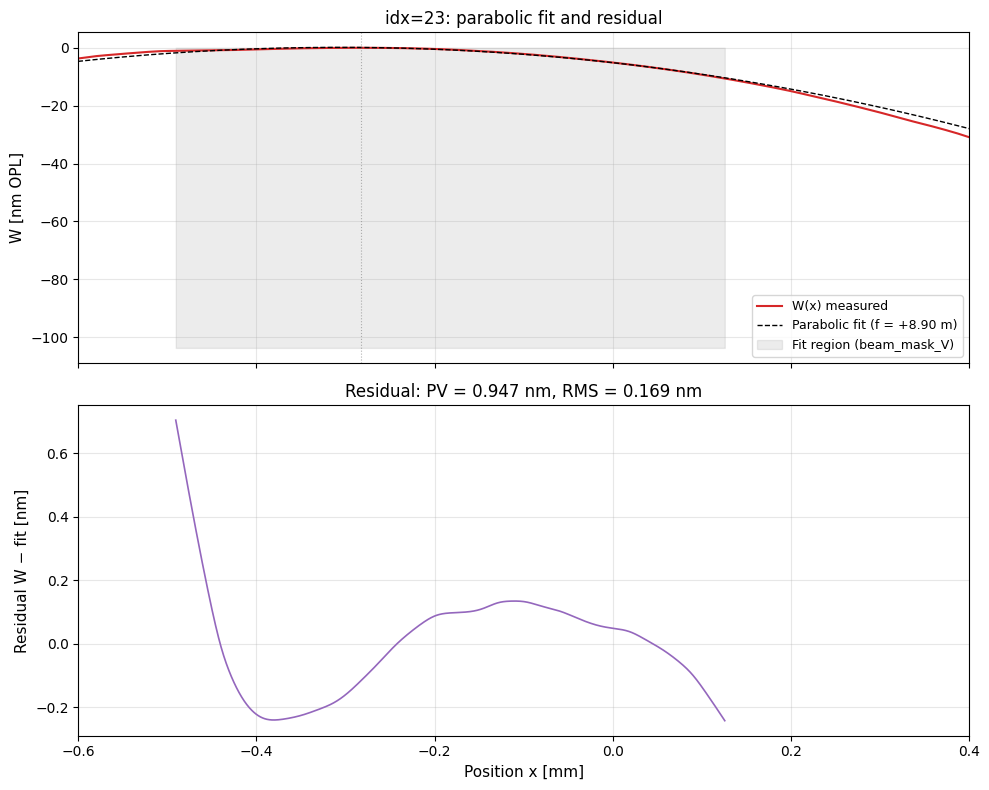

In [152]:
# --- Predict focal length from parabolic fit to W(x) ---
# For a converging wave W = -k x²/(2f), so f = -k/(2 a₂) where k = 2π/λ.
# Fit region: beam_mask_V (I₀ > 1/e², gap-filled). This excludes the no-fringe
# right lobe where W comes from integrating noise.

mask_fit = fill_mask_gaps(I0 > 0.05 * np.max(I0))

poly = np.polyfit(x_m[mask_fit], wavefront_rad[mask_fit], 2)
a2   = poly[0]

k_1_m  = 2 * np.pi / wavelength_m
f_pred = -k_1_m / (2 * a2)

# Residual (higher-order aberrations after parabola subtraction)
W_para     = np.polyval(poly, x_m)
W_resid    = wavefront_rad - W_para
W_resid_nm = W_resid * wavelength_m / (2*np.pi) * 1e9

print(f"Parabolic fit to W(x):")
print(f"  a₂          = {a2:.4e} rad/m²")
print(f"  f_pred      = {f_pred:+.3f} m  ({'converging (focus downstream)' if f_pred > 0 else 'diverging (virtual focus upstream)'})")
print(f"  cross-check: z_focus from σ_rms minimum = {z_focus:+.3f} m")
print(f"  residual (over fit region): PV = {np.ptp(W_resid_nm[mask_fit]):.4f} nm, "
      f"RMS = {np.std(W_resid_nm[mask_fit]):.4f} nm")

# --- Plot: fit and residual ---
W_para_nm = W_para * wavelength_m / (2*np.pi) * 1e9

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
ax.plot(x_m * 1e3, wavefront_nm, 'C3', lw=1.5, label='W(x) measured')
ax.plot(x_m * 1e3, W_para_nm,    'k--', lw=1, label=f'Parabolic fit (f = {f_pred:+.2f} m)')
ax.fill_between(x_m * 1e3, np.min(wavefront_nm), np.max(wavefront_nm),
                where=mask_fit, color='gray', alpha=0.15, label='Fit region (beam_mask_V)')
ax.axvline(x_m[x_c_phase] * 1e3, color='gray', ls=':', lw=0.8, alpha=0.6)
ax.set_ylabel('W [nm OPL]', fontsize=11)
ax.set_title(f'idx={idx}: parabolic fit and residual', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_m * 1e3, np.where(mask_fit, W_resid_nm, np.nan), 'C4', lw=1.2)
ax.set_xlabel('Position x [mm]', fontsize=11)
ax.set_ylabel('Residual W − fit [nm]', fontsize=11)
ax.set_title(f'Residual: PV = {np.ptp(W_resid_nm[mask_fit]):.3f} nm, RMS = {np.std(W_resid_nm[mask_fit]):.3f} nm')
ax.grid(True, alpha=0.3)

ax.set_xlim(-.6, .4)
plt.tight_layout()
plt.show()

#### 4. Consolidated pipeline

The function `run_pipeline(idx)` packages §1–§3 into a single call: envelope extraction → centroid → wavefront reconstruction → propagation → parabolic fit. Below the function definition we demonstrate it on idx = 22 (reproduces §1–§3 above) and idx = 24 (a different frame, to verify portability).

**Parameters and methods, locked in from §1–§3:**

| Step | Method | Notes |
|---|---|---|
| Carrier detection | `argmax` of \|FFT\| in 120–180 cyc/mm band | Gives $k_\text{peak}$ (measured) |
| 0th-order filter | Gaussian low-pass at $f=0$, σ = $k_\text{peak}/5$ | → $I_0(x)$ |
| +1-order filter | Gaussian bandpass at $f=k_\text{peak}$, σ = $k_\text{peak}/10$ | → $A_{+1}(x)$ |
| Beam mask | $I_0 > I_0^\text{peak}/e^2$, gap-filled | For centroid |
| Phase reference | Centroid of $\|A_{+1}\|^2$ under beam mask | → $x_c$, replaces $N/2$ |
| Carrier ramp | $2\pi/p \cdot x$ (predicted from grating) | Independent of $k_\text{peak}$ |
| Field amplitude | $A(x) = \|A_{+1}(x)\|$ | Path D: no thresholding |
| Propagation | `monoplus.propTF`, σ_rms from second moment | → $z_\text{focus}$ |
| Parabolic fit | Fit $W(x)$ on $I_0 > 5\%$ of peak, gap-filled | → $f_\text{pred} = -k/(2 a_2)$ |

**Key distinction:** $k_\text{peak}$ (measured FFT peak, frame-dependent, used for filter centering) vs $k_\text{carrier} = 1/p$ (fixed grating pitch, used for the ramp subtraction). Filter follows the data; ramp follows the grating geometry.

The function returns a dict with the full pipeline output: envelopes, centroid, wavefront, propagation results, and trust masks.

In [163]:
# --- Consolidated single-frame pipeline (envelope → centroid → recon → propagation) ---

def run_pipeline(idx_run, y_roi=y_roi, z_T=z_T, grating_pitch_m=grating_pitch_m,
                 dx_m=dx_m, energy_eV=energy_eV, images=images,
                 z_range_m=None, plot=True):
    """
    Full WFS pipeline for a single frame.

    Returns dict with:
      I0, A1, V_x_norm, x_c_phase,
      wavefront_nm, wavefront_rad,
      f_pred, z_focus, sigma_focus, sigma_rms, z_range_m,
      x_m, beam_mask_V, mask_fit, k_peak
    """
    # ===== Setup =====
    line_avg     = np.mean(images[idx_run][:, y_roi], axis=1)
    N            = len(line_avg)
    freq         = np.fft.fftshift(np.fft.fftfreq(N, dx_m))
    fft_avg      = np.fft.fftshift(np.fft.fft(line_avg))
    x_m          = (np.arange(N) - N // 2) * dx_m
    wavelength_m = 1.24e-6 / energy_eV[idx_run]

    # Measured +1-order peak (for filter centering)
    search_mask  = (freq >= 120e3) & (freq <= 180e3)
    k_peak       = freq[np.argmax(np.abs(fft_avg) * search_mask)]

    # ===== Envelope extraction =====
    sigma_0th = k_peak / 5
    sigma_1st = k_peak / 10

    gauss_lp     = np.exp(-0.5 * (freq / sigma_0th)**2)
    complex_0th  = np.fft.ifft(np.fft.ifftshift(fft_avg * gauss_lp))
    I0           = np.abs(complex_0th)**2

    gauss_bp     = np.exp(-0.5 * ((freq - k_peak) / sigma_1st)**2)
    complex_1st  = np.fft.ifft(np.fft.ifftshift(fft_avg * gauss_bp))
    A1           = np.abs(complex_1st)

    # Beam mask: I₀ > I₀_peak/e², gap-filled
    beam_mask_V = fill_mask_gaps(I0 > np.exp(-2) * np.max(I0))

    # Visibility (peak-normalized within beam_mask_V), kept for diagnostics
    V_x        = np.zeros_like(I0)
    V_x[beam_mask_V] = A1[beam_mask_V] / np.sqrt(I0[beam_mask_V])
    V_x_norm   = V_x / np.max(V_x[beam_mask_V])

    # ===== Centroid (option c, 1/e² mask, |A_+1|² weighting) =====
    x_idx     = np.arange(N)
    x_c_phase = int(np.average(x_idx[beam_mask_V], weights=A1[beam_mask_V]**2))

    # ===== Wavefront reconstruction =====
    # Filter centered at k_peak (measured); ramp uses 2π/p (predicted)
    phase_unwrapped = np.unwrap(np.angle(complex_1st))
    phase_centered  = phase_unwrapped - phase_unwrapped[x_c_phase]
    carrier_ramp    = 2*np.pi/grating_pitch_m * x_m
    carrier_ramp    = carrier_ramp - carrier_ramp[x_c_phase]
    delta_phi       = phase_centered - carrier_ramp
    W_temp          = -np.cumsum(delta_phi) * dx_m * grating_pitch_m / wavelength_m / z_T
    wavefront_rad   = W_temp - W_temp[x_c_phase]
    wavefront_nm    = wavefront_rad * wavelength_m / (2*np.pi) * 1e9

    # ===== Parabolic fit (wider mask: I₀ > 5% of peak) =====
    mask_fit  = fill_mask_gaps(I0 > 0.05 * np.max(I0))
    poly      = np.polyfit(x_m[mask_fit], wavefront_rad[mask_fit], 2)
    a2        = poly[0]
    k_1_m     = 2*np.pi / wavelength_m
    f_pred    = -k_1_m / (2*a2)

    W_para     = np.polyval(poly, x_m)
    W_resid_nm = (wavefront_rad - W_para) * wavelength_m / (2*np.pi) * 1e9

    # ===== Propagation (Path D: E = |A_+1| · exp(iW), no masking) =====
    E_det = A1 * np.exp(1j * wavefront_rad)

    L_m = N * dx_m
    if z_range_m is None:
        # Default range: span ±1.5 × predicted focus
        z_max     = max(abs(f_pred) * 1.5, 1.0)
        z_min     = -0.3 * z_max if f_pred > 0 else -z_max
        z_max_pos =  z_max       if f_pred > 0 else 0.3 * z_max
        z_range_m = np.linspace(z_min, z_max_pos, 71)
    Z = len(z_range_m)

    E_caustic = np.zeros((N, Z), dtype=complex)
    for i_z, z in enumerate(z_range_m):
        E_caustic[:, i_z] = mp.propTF(E_det, L_m, wavelength_m, z)
    I_caustic = np.abs(E_caustic)**2
    sigma_rms = mp.secondmomt(Z, x_m, E_caustic)

    i_focus     = np.argmin(sigma_rms)
    z_focus     = z_range_m[i_focus]
    sigma_focus = sigma_rms[i_focus]

    # ===== Plot =====
    if plot:
        fig, axes = plt.subplots(3, 2, figsize=(16, 12))

        # Row 1: envelopes + V(x)
        ax = axes[0, 0]
        ax.plot(x_m*1e3, I0/np.max(I0),  'C0', lw=1.5, label='I₀ (norm)')
        ax.plot(x_m*1e3, (A1**2)/np.max(A1**2), 'C3', lw=1.5, label='|A_+1|² (norm)')
        ax.axvline(x_m[x_c_phase]*1e3, color='gray', ls=':', alpha=0.6, label='x_c_phase')
        ax.set_xlabel('x [mm]'); ax.set_ylabel('Normalized intensity')
        ax.set_title(f'idx={idx_run} (E={energy_eV[idx_run]:.0f} eV, B={bender_um[idx_run]:.0f} µm): envelopes')
        ax.set_xlim(-.75, .75); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

        ax = axes[0, 1]
        ax.plot(x_m*1e3, np.where(beam_mask_V, V_x_norm, np.nan), 'C2', lw=1.5, label='V(x)')
        ax.plot(x_m*1e3, I0/np.max(I0), 'C0', lw=0.8, alpha=0.4, label='I₀ (ref)')
        ax.set_xlabel('x [mm]'); ax.set_ylabel('V(x)'); ax.set_title('Visibility')
        ax.set_xlim(-.75, .75); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

        # Row 2: wavefront + parabolic fit, residual
        ax = axes[1, 0]
        W_para_nm = W_para * wavelength_m / (2*np.pi) * 1e9
        ax.plot(x_m*1e3, wavefront_nm, 'C3', lw=1.5, label='W(x) measured')
        ax.plot(x_m*1e3, W_para_nm,    'k--', lw=1, label=f'Parabolic fit (f={f_pred:+.2f} m)')
        ax.fill_between(x_m*1e3, np.min(wavefront_nm[mask_fit]) - 2, np.max(wavefront_nm[mask_fit]) + 2,
                        where=mask_fit, color='gray', alpha=0.15, label='Fit region')
        ax.axvline(x_m[x_c_phase]*1e3, color='gray', ls=':', alpha=0.6)
        ax.set_xlabel('x [mm]'); ax.set_ylabel('W [nm OPL]')
        ax.set_title(f'Wavefront + parabolic fit')
        ax.set_ylim(np.min(wavefront_nm[mask_fit]) - 5, 5)
        ax.set_xlim(-.75, .75); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

        ax = axes[1, 1]
        ax.plot(x_m*1e3, np.where(mask_fit, W_resid_nm, np.nan), 'C4', lw=1.2)
        ax.set_xlabel('x [mm]'); ax.set_ylabel('Residual [nm]')
        ax.set_title(f'W − parabola (residual): PV={np.ptp(W_resid_nm[mask_fit]):.3f} nm, RMS={np.std(W_resid_nm[mask_fit]):.3f} nm')
        ax.set_xlim(-.75, .75); ax.grid(True, alpha=0.3)

        # Row 3: caustic + σ_rms(z)
        ax = axes[2, 0]
        I_caustic_norm = I_caustic / np.max(I_caustic, axis=0, keepdims=True)
        im = ax.imshow(I_caustic_norm,
                       extent=(z_range_m[0], z_range_m[-1], x_m[0]*1e3, x_m[-1]*1e3),
                       aspect='auto', origin='lower', cmap='inferno')
        ax.axvline(z_focus, color='cyan',   lw=1, ls='--', alpha=0.8, label=f'σ_rms min: {z_focus:+.2f} m')
        ax.axvline(f_pred,  color='yellow', lw=1, ls=':',  alpha=0.8, label=f'f_pred:     {f_pred:+.2f} m')
        ax.set_xlabel('z [m]'); ax.set_ylabel('x [mm]')
        ax.set_title('Caustic |E(x,z)|²')
        ax.set_ylim(-.75, .75); ax.legend(fontsize=9, loc='upper right')
        plt.colorbar(im, ax=ax)

        ax = axes[2, 1]
        ax.plot(z_range_m, sigma_rms*1e6, 'C0', lw=1.5)
        ax.axvline(z_focus, color='cyan',   lw=1, ls='--', alpha=0.8)
        ax.axvline(f_pred,  color='yellow', lw=1, ls=':',  alpha=0.8)
        ax.scatter([z_focus], [sigma_focus*1e6], color='red', s=40, zorder=5,
                   label=f'min: σ={sigma_focus*1e6:.1f} µm at z={z_focus:+.2f} m')
        ax.set_xlabel('z [m]'); ax.set_ylabel('σ_rms [µm]')
        ax.set_title('Beam size vs z')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # Print summary
    print(f"=== idx={idx_run} (E={energy_eV[idx_run]:.0f} eV, B={bender_um[idx_run]:.0f} µm) ===")
    print(f"  k_peak     = {k_peak*1e-3:.2f} cyc/mm")
    print(f"  x_c_phase  = pixel {x_c_phase}, x = {x_m[x_c_phase]*1e3:+.4f} mm")
    print(f"  f_pred     = {f_pred:+.3f} m  (parabolic fit, I₀>5%)")
    print(f"  z_focus    = {z_focus:+.3f} m  (σ_rms minimum)")
    print(f"  σ_focus    = {sigma_focus*1e6:.2f} µm")
    print(f"  W residual = PV {np.ptp(W_resid_nm[mask_fit]):.3f} nm, RMS {np.std(W_resid_nm[mask_fit]):.3f} nm")

    return dict(I0=I0, A1=A1, V_x_norm=V_x_norm, x_c_phase=x_c_phase,
                wavefront_nm=wavefront_nm, wavefront_rad=wavefront_rad,
                f_pred=f_pred, z_focus=z_focus, sigma_focus=sigma_focus,
                sigma_rms=sigma_rms, z_range_m=z_range_m, x_m=x_m,
                beam_mask_V=beam_mask_V, mask_fit=mask_fit, k_peak=k_peak)


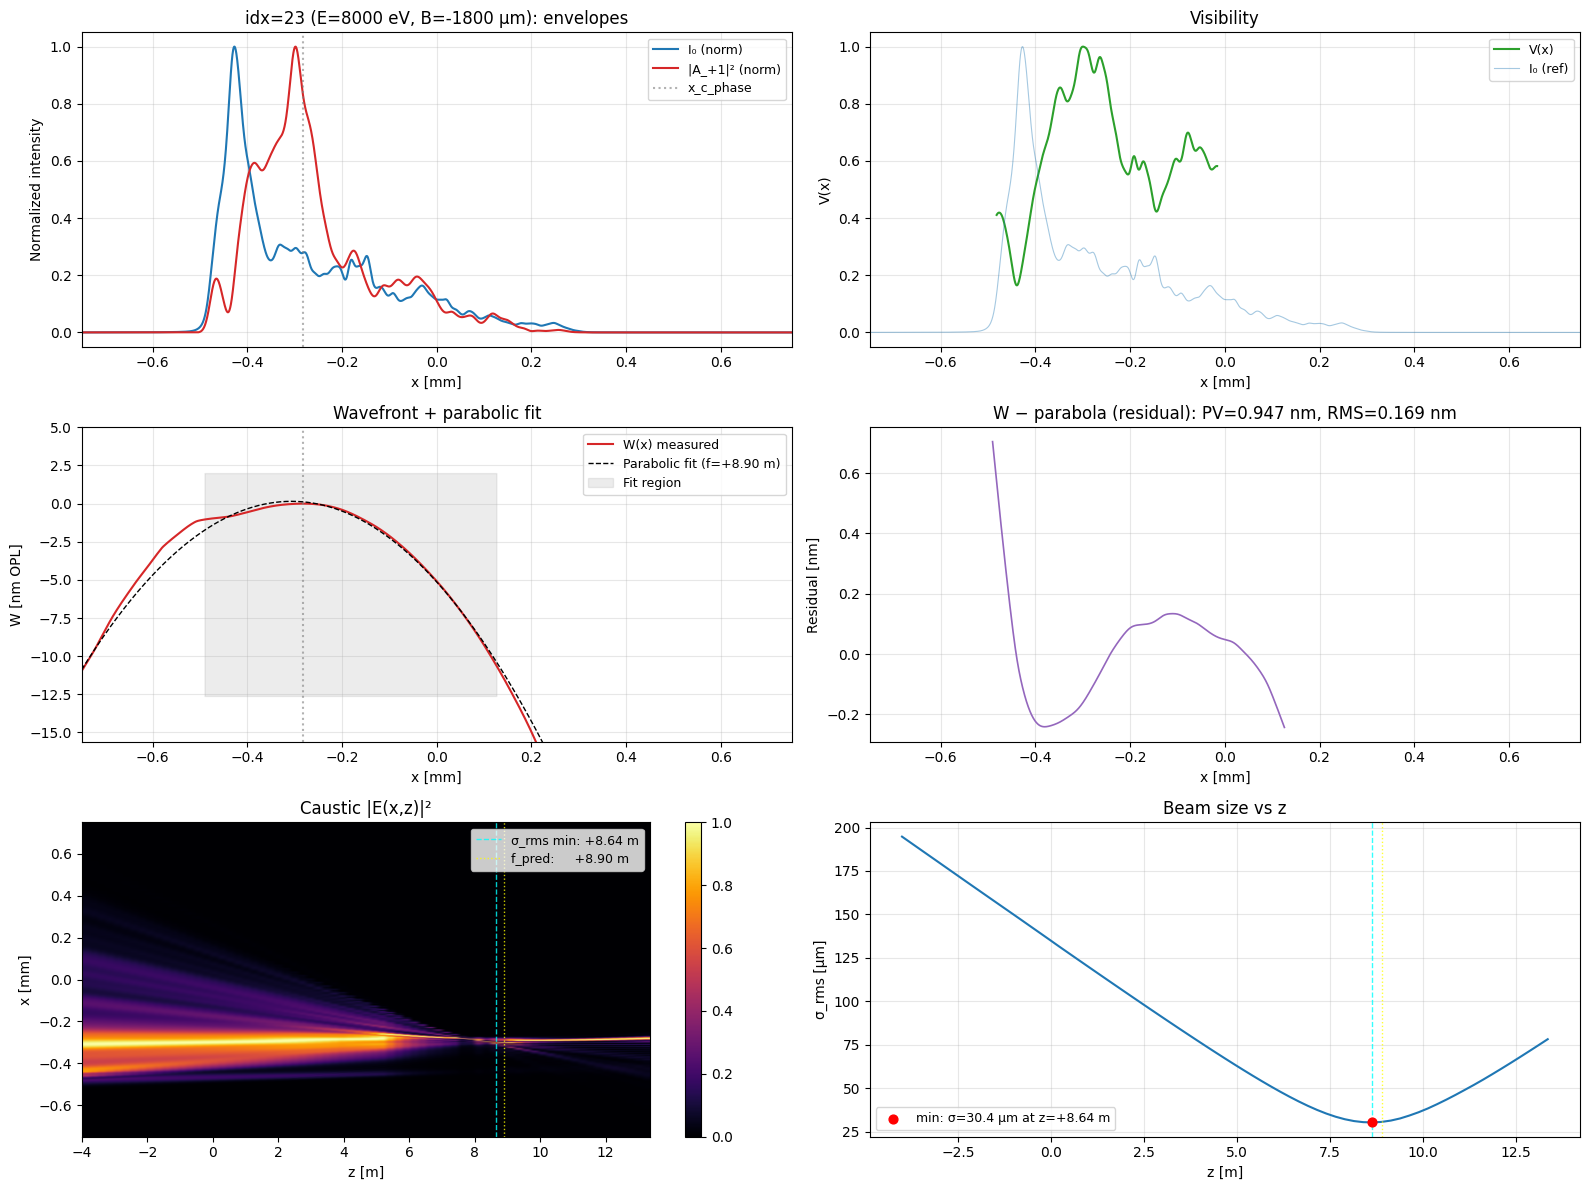

=== idx=23 (E=8000 eV, B=-1800 µm) ===
  k_peak     = 148.08 cyc/mm
  x_c_phase  = pixel 1248, x = -0.2822 mm
  f_pred     = +8.901 m  (parabolic fit, I₀>5%)
  z_focus    = +8.640 m  (σ_rms minimum)
  σ_focus    = 30.42 µm
  W residual = PV 0.947 nm, RMS 0.169 nm


In [164]:
result_23 = run_pipeline(23)

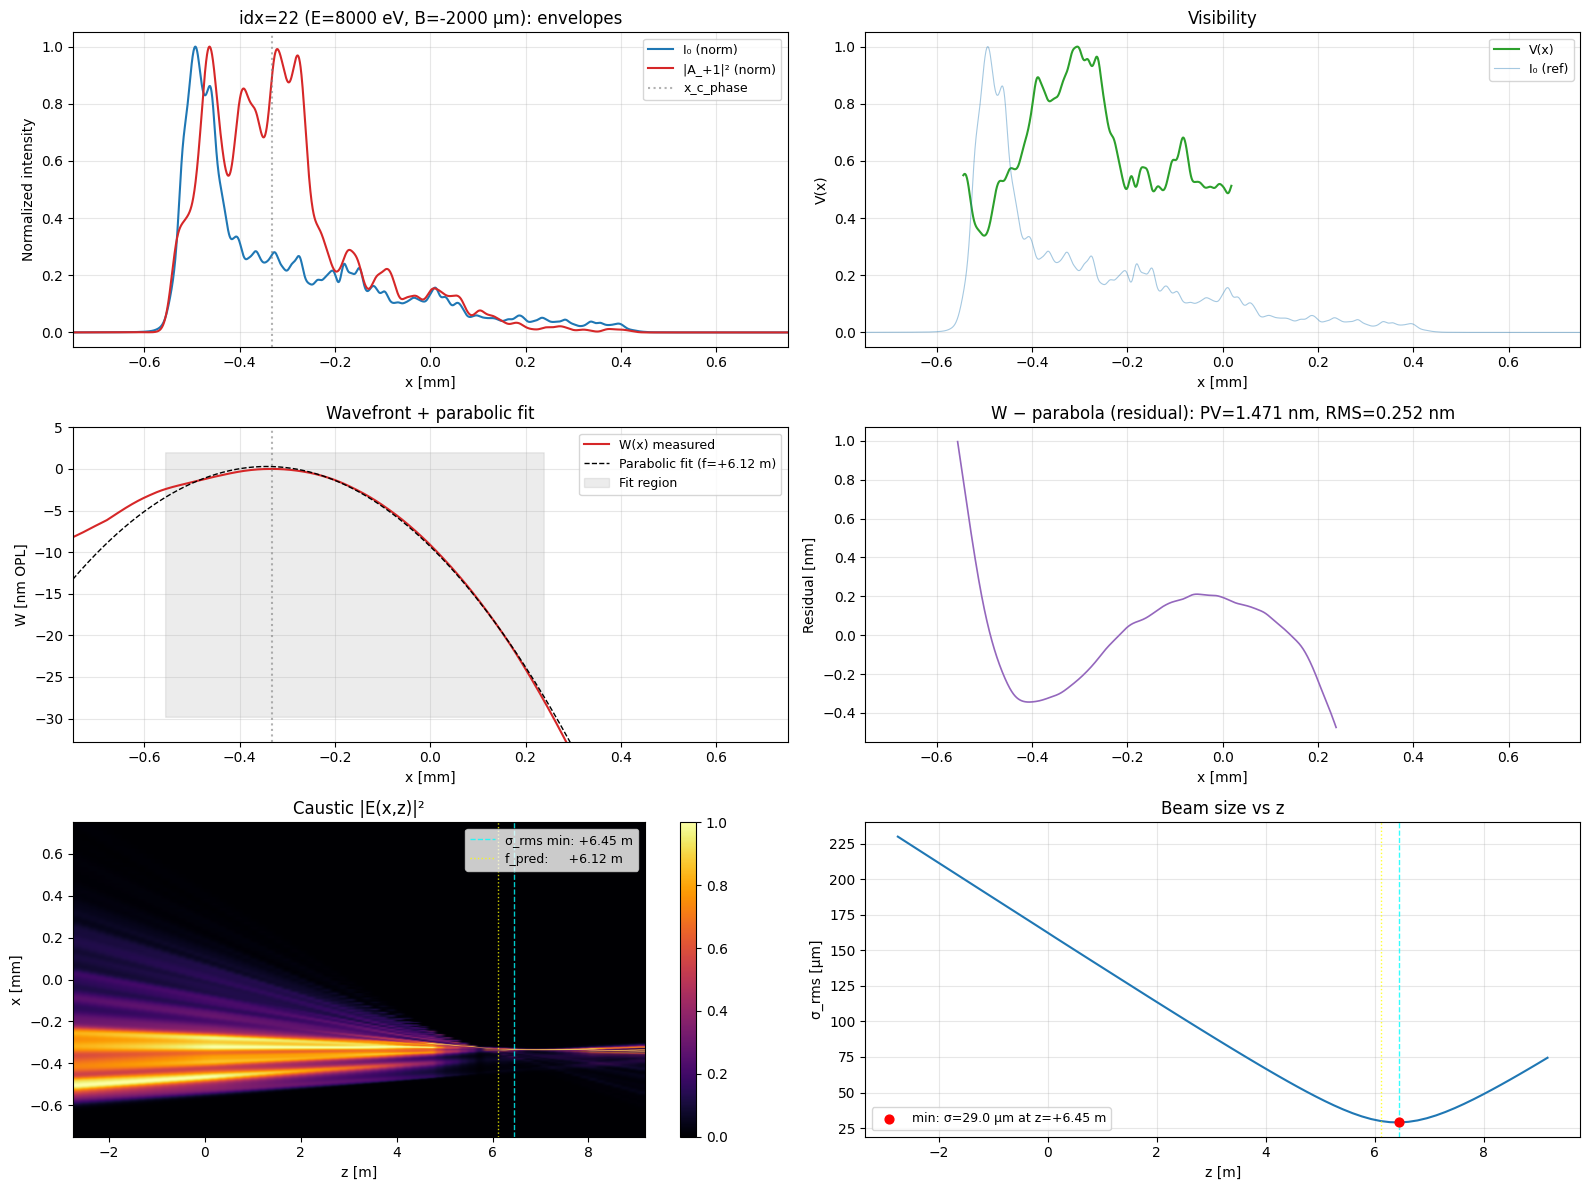

=== idx=22 (E=8000 eV, B=-2000 µm) ===
  k_peak     = 150.35 cyc/mm
  x_c_phase  = pixel 1144, x = -0.3322 mm
  f_pred     = +6.115 m  (parabolic fit, I₀>5%)
  z_focus    = +6.447 m  (σ_rms minimum)
  σ_focus    = 28.96 µm
  W residual = PV 1.471 nm, RMS 0.252 nm


In [165]:
result_22 = run_pipeline(22)

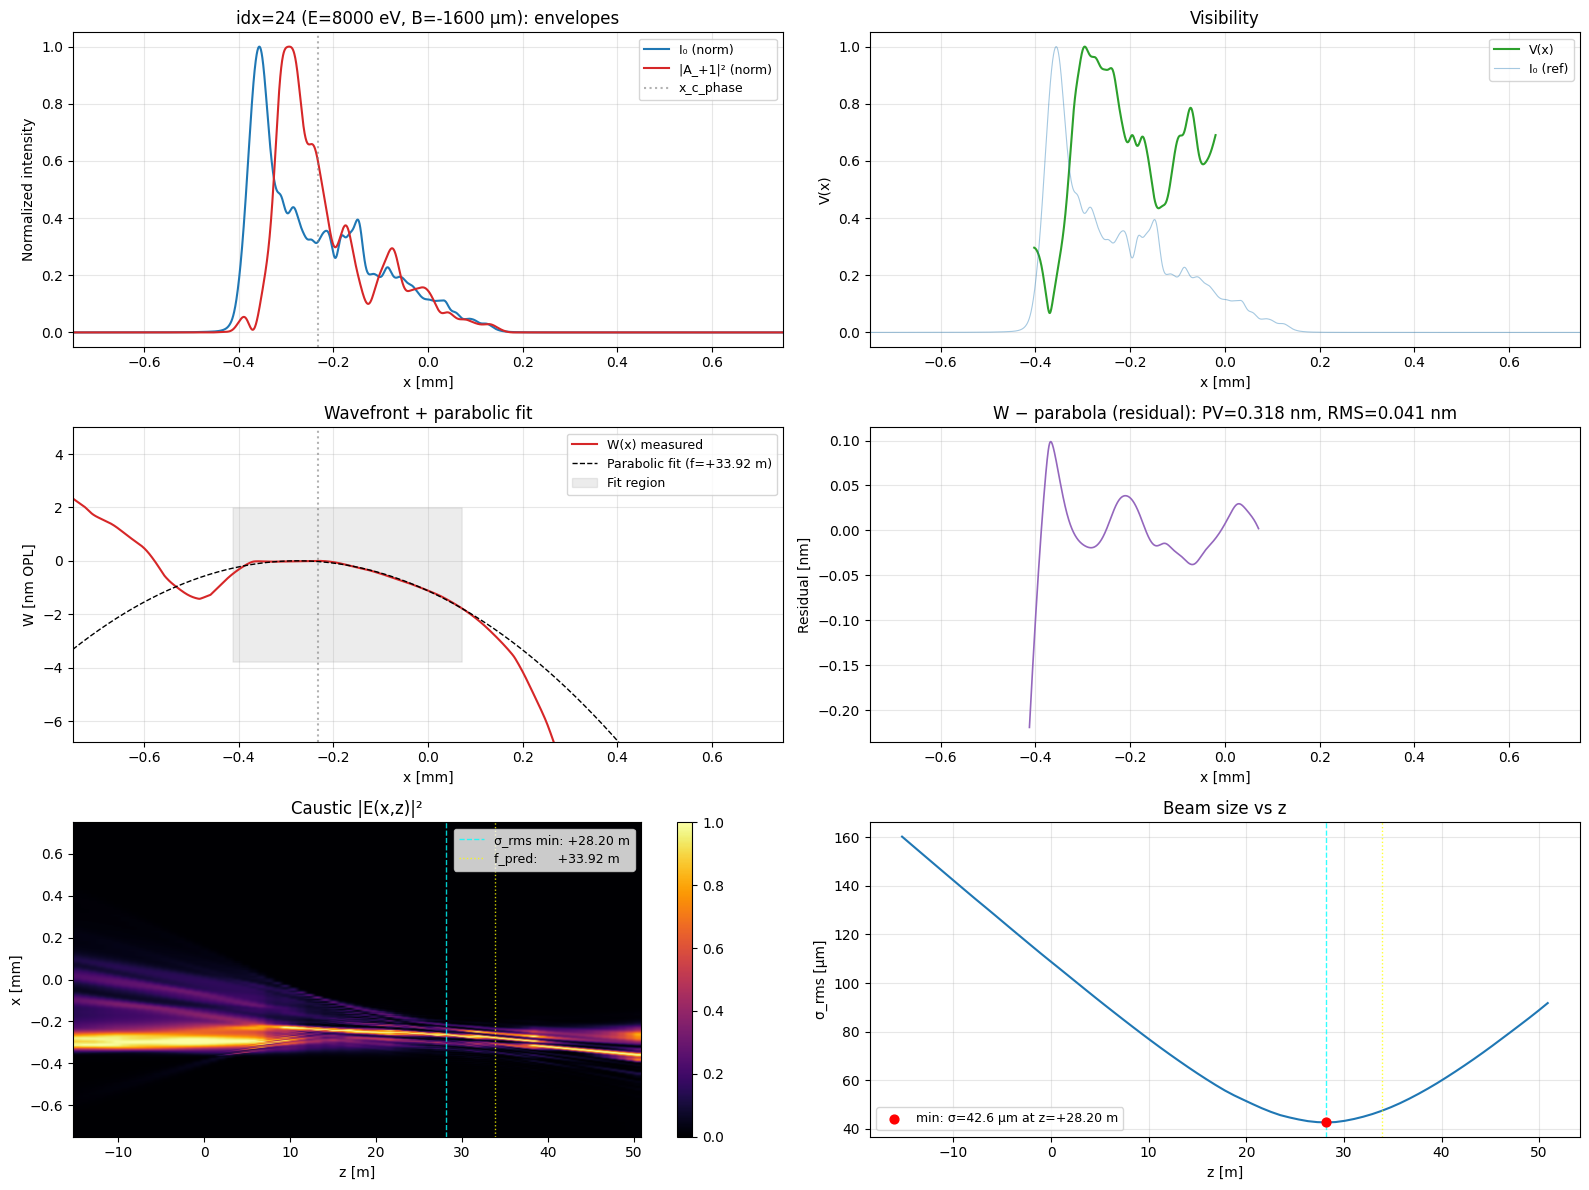

=== idx=24 (E=8000 eV, B=-1600 µm) ===
  k_peak     = 144.11 cyc/mm
  x_c_phase  = pixel 1350, x = -0.2333 mm
  f_pred     = +33.918 m  (parabolic fit, I₀>5%)
  z_focus    = +28.200 m  (σ_rms minimum)
  σ_focus    = 42.63 µm
  W residual = PV 0.318 nm, RMS 0.041 nm


In [166]:
result_24 = run_pipeline(24)

## Different Bendings at 8000 eV


### Data extraction

The selection of ROI may vary depending on the bending we chose. Thus, in the following we first survey how the image look, and how the ROI choice may affect the FFT spectrum. 

In [ ]:
# --- Visual survey: all 11 bender settings at 8000 eV ---
idx_sweep = range(22, 33)   # 11 frames: bender = −2000 → 0 µm

panels = [images[i].T for i in idx_sweep]
stacked = np.vstack(panels)

fig, ax = plt.subplots(figsize=(10, 15))
ax.imshow(stacked, cmap='inferno', aspect='auto')

# Draw horizontal separators between frames
n_y = panels[0].shape[0]
for k in range(1, len(idx_sweep)):
    ax.axhline(k * n_y - 0.5, color='cyan', linewidth=0.8, linestyle='--')

# Label each panel with its bender value
for k, i in enumerate(idx_sweep):
    ax.text(10, k * n_y + n_y * 0.05,
            f'idx={i}  bender={bender_um[i]:.0f} µm',
            color='white', fontsize=8, va='top')

ax.set_title('Bender sweep at 8000 eV — stacked frames (top: −2000 µm, bottom: 0 µm)')
ax.set_xlabel('x [pixels]')
ax.set_ylabel('y [pixels, repeated per frame]')
plt.tight_layout()
plt.show()

In [ ]:
# --- ROI verification: line cuts for all bender settings ---
idx_sweep = range(22, 33)
y_cuts = [470, 475, 480, 485]
colors = ['C0', 'C1', 'C2', 'C3', 'C4']

fig, axes = plt.subplots(11, 1, figsize=(15, 40))
axes = axes.ravel()

for k, idx in enumerate(idx_sweep):
    ax = axes[k]
    for y, col in zip(y_cuts, colors):
        profile = images[idx][:, y]
        x_um = np.arange(len(profile)) * dx_m * 1e6
        # ax.plot(x_um[750:900], profile[750:900], linewidth=1, color=col, label=f'y={y}')
        ax.plot(x_um, profile, linewidth=1, color=col, label=f'y={y}')
    ax.set_xlim(300, 1100)
    ax.set_xlabel('Position [µm]', fontsize=8)
    ax.set_ylabel('Counts', fontsize=8)
    ax.set_title(f'idx={idx}  bender={bender_um[idx]:.0f} µm', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.tick_params(labelsize=7)

# Hide the unused 12th subplot
axes[-1].set_visible(False)

fig.suptitle('ROI verification: y-line cuts at 470, 480, 490 — bender sweep (8000 eV)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# --- FFT verification: carrier check for all bender settings ---
idx_sweep = range(22, 33)
y_cuts    = [470, 475, 480, 485]
y_roi     = slice(470, 486)

for idx in idx_sweep:
    line_avg = np.mean(images[idx][:, y_roi], axis=1)
    freq     = np.fft.fftshift(np.fft.fftfreq(len(line_avg), dx_m))
    fft_avg  = np.fft.fftshift(np.fft.fft(line_avg))

    # Carrier detection within 120–180 cycles/mm
    search_mask  = (freq >= 120e3) & (freq <= 180e3)
    carrier_idx  = np.argmax(np.abs(fft_avg) * search_mask)
    k_carrier    = freq[carrier_idx]

    fig, axes = plt.subplots(2, 1, figsize=(12, 6))

    for ax in axes:
        ax.axvline(1/grating_pitch_m * 1e-3, color='red',   linestyle='--', linewidth=1, label=f'Ideal: {1/grating_pitch_m*1e-3:.1f} cyc/mm')
        ax.axvline(k_carrier * 1e-3,          color='orange', linestyle='--', linewidth=1, label=f'Measured: {k_carrier*1e-3:.1f} cyc/mm')
        ax.set_xlim(0, 300)
        ax.set_xlabel('Spatial frequency [cycles/mm]')
        ax.set_ylabel('FFT magnitude')
        ax.grid(True, alpha=0.3, which='both')

    axes[0].semilogy(freq * 1e-3, np.abs(fft_avg), linewidth=1.5, color='C0', label='ROI avg (470–485)')
    axes[0].set_title(f'FFT — ROI average | idx={idx}  bender={bender_um[idx]:.0f} µm')
    axes[0].legend(fontsize=8)

    for y in y_cuts:
        prof  = images[idx][:, y]
        fft_y = np.fft.fftshift(np.fft.fft(prof))
        axes[1].semilogy(freq * 1e-3, np.abs(fft_y), linewidth=1, alpha=0.7, label=f'y={y}')
    axes[1].set_title(f'FFT — individual cuts | idx={idx}  bender={bender_um[idx]:.0f} µm')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

### Phase reconstruction

In [ ]:
# Carrier detection and Gaussian filter 
idx_sweep = range(22, 33)
y_roi     = slice(470, 485)
rec       = {}

for idx in idx_sweep:
    line_avg = np.mean(images[idx][:, y_roi], axis=1)
    N        = len(line_avg)
    freq     = np.fft.fftshift(np.fft.fftfreq(N, dx_m))
    fft_avg  = np.fft.fftshift(np.fft.fft(line_avg))

    search_mask  = (freq >= 120e3) & (freq <= 180e3)
    carrier_idx  = np.argmax(np.abs(fft_avg) * search_mask)
    k_carrier    = freq[carrier_idx]

    sigma        = k_carrier / 5.0
    gauss_filt   = np.exp(-0.5 * ((freq - k_carrier) / sigma)**2)
    fft_filtered = fft_avg * gauss_filt

    rec[idx] = dict(freq=freq, fft_avg=fft_avg,
                    fft_filtered=fft_filtered, k_carrier=k_carrier)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.semilogy(freq * 1e-3, np.abs(fft_avg),      linewidth=1,   alpha=0.6, label='Original')
    ax.semilogy(freq * 1e-3, np.abs(fft_filtered), linewidth=1.5, label='Filtered')
    ax.axvline(1/grating_pitch_m * 1e-3, color='red',    linestyle='--', linewidth=1, label=f'Ideal: {1/grating_pitch_m*1e-3:.1f} cyc/mm')
    ax.axvline(k_carrier * 1e-3,          color='orange', linestyle='--', linewidth=1, label=f'Measured: {k_carrier*1e-3:.1f} cyc/mm')
    ax.set_xlim(0, 300)
    ax.set_ylim(1e-2, np.abs(fft_avg).max() * 1.2)
    ax.set_xlabel('Spatial frequency [cycles/mm]')
    ax.set_ylabel('FFT magnitude')
    ax.set_title(f'FFT + filter | idx={idx}  bender={bender_um[idx]:.0f} µm')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

# Carrier frequency summary table
k_ideal = 1 / grating_pitch_m
print(f"{'idx':>5}  {'bender (µm)':>12}  {'k_meas (cyc/mm)':>17}")
print("-" * 40)
for idx in idx_sweep:
    k = rec[idx]['k_carrier']
    print(f"{idx:>5}  {bender_um[idx]:>12.0f}  {k*1e-3:>17.2f}")

In [ ]:
# ifft + unwrapping + carrier removal + integration → wavefront 

for idx in idx_sweep:
    phase_centered = rec[idx]['fft_filtered']
    N              = len(phase_centered)

    complex_field   = np.fft.ifft(np.fft.ifftshift(rec[idx]['fft_filtered']))
    phase_unwrapped = np.unwrap(np.angle(complex_field))
    phase_centered  = phase_unwrapped - phase_unwrapped[N // 2]
    x_m             = (np.arange(N) - N // 2) * dx_m

    carrier_ramp  = 2 * np.pi / grating_pitch_m * x_m
    carrier_ramp  = carrier_ramp - carrier_ramp[N // 2]
    delta_phi     = phase_centered - carrier_ramp

    W_temp        = -np.cumsum(delta_phi) * dx_m * grating_pitch_m / wavelength_m / z_T
    wavefront_rad = W_temp - W_temp[N // 2]
    wavefront_nm  = wavefront_rad * wavelength_m / (2 * np.pi) * 1e9

    rec[idx]['x_m']           = x_m
    rec[idx]['delta_phi']     = delta_phi
    rec[idx]['wavefront_rad'] = wavefront_rad
    rec[idx]['wavefront_nm']  = wavefront_nm

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))

    ax = axes[0]
    ax.plot(x_m * 1e3, delta_phi, linewidth=1)
    ax.set_xlabel('Position [mm]')
    ax.set_ylabel('Δφ [rad]')
    ax.set_title(f'Differential phase | idx={idx}  bender={bender_um[idx]:.0f} µm')
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(x_m * 1e3, wavefront_nm, linewidth=1)
    ax.set_xlabel('Position [mm]')
    ax.set_ylabel('Wavefront [nm OPL]')
    ax.set_title(f'Reconstructed wavefront | idx={idx}  bender={bender_um[idx]:.0f} µm')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"idx={idx}  bender={bender_um[idx]:.0f} µm  |  PV={wavefront_nm.max()-wavefront_nm.min():.2f} nm  RMS={np.std(wavefront_nm):.2f} nm")

In [ ]:
# --- C4: Overlay of reconstructed wavefronts (three groups) ---
groups = [list(idx_sweep)[:4], list(idx_sweep)[4:7], list(idx_sweep)[7:]]

for group in groups:
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx in group:
        x_m          = rec[idx]['x_m']
        wavefront_nm = rec[idx]['wavefront_nm']
        ax.plot(x_m * 1e3, wavefront_nm, linewidth=1,
                label=f'idx={idx}  bender={bender_um[idx]:.0f} µm')
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-85, 55)
    ax.set_xlabel('Position [mm]')
    ax.set_ylabel('Wavefront [nm OPL]')
    ax.set_title('Reconstructed wavefronts — bender sweep at 8000 eV')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Extra attempts

1. Detrending
2. Effects of filter selection 

#### Detrending

Not really useful in our case here. 

In [ ]:
# Detrended wavefronts 
groups = [list(idx_sweep)[:4], list(idx_sweep)[4:7], list(idx_sweep)[7:]]

for group in groups:
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx in group:
        x_m          = rec[idx]['x_m']
        wavefront_rad = rec[idx]['wavefront_rad']

        _, aberrations_rad, _ = wfu.detrending(wavefront_rad, x_m, fit_order=2)
        aberrations_nm = aberrations_rad * rec[idx].get('wavelength_m', wavelength_m) / (2 * np.pi) * 1e9

        ax.plot(x_m * 1e3, aberrations_nm, linewidth=1,
                label=f'idx={idx}  bender={bender_um[idx]:.0f} µm')

    ax.set_xlim(-0.5, 0.5)
    ax.set_xlabel('Position [mm]')
    ax.set_ylabel('Residual aberration [nm OPL]')
    ax.set_title('Detrended wavefronts (parabola removed) — bender sweep at 8000 eV')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Change the filter `sigma`? 

Currently we are using `sigma = k_carrier/5`; what if `sigma = k_carrier/10`? 


In [ ]:
# --- C_sharp_1: Rerun carrier filter with sharper sigma ---
sigma_ratio_sharp = 10   # compare to default of 5
rec_sharp = {}

for idx in idx_sweep:
    line_avg = np.mean(images[idx][:, y_roi], axis=1)
    N        = len(line_avg)
    freq     = np.fft.fftshift(np.fft.fftfreq(N, dx_m))
    fft_avg  = np.fft.fftshift(np.fft.fft(line_avg))

    search_mask  = (freq >= 120e3) & (freq <= 180e3)
    carrier_idx  = np.argmax(np.abs(fft_avg) * search_mask)
    k_carrier    = freq[carrier_idx]

    sigma        = k_carrier / sigma_ratio_sharp
    gauss_filt   = np.exp(-0.5 * ((freq - k_carrier) / sigma)**2)
    fft_filtered = fft_avg * gauss_filt

    rec_sharp[idx] = dict(freq=freq, fft_avg=fft_avg,
                          fft_filtered=fft_filtered, k_carrier=k_carrier)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.semilogy(freq * 1e-3, np.abs(fft_avg),                        linewidth=1,   alpha=0.5, label='Original')
    ax.semilogy(freq * 1e-3, np.abs(rec[idx]['fft_filtered']),        linewidth=1.5, alpha=0.7, label=f'σ = k/5  (default)')
    ax.semilogy(freq * 1e-3, np.abs(fft_filtered),                    linewidth=1.5, label=f'σ = k/{sigma_ratio_sharp}  (sharp)')
    ax.axvline(k_carrier * 1e-3, color='orange', linestyle='--', linewidth=1, label=f'Carrier: {k_carrier*1e-3:.1f} cyc/mm')
    ax.set_xlim(0, 300)
    ax.set_ylim(1e-2, np.abs(fft_avg).max() * 1.2)
    ax.set_xlabel('Spatial frequency [cycles/mm]')
    ax.set_ylabel('FFT magnitude')
    ax.set_title(f'Filter comparison | idx={idx}  bender={bender_um[idx]:.0f} µm')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

In [ ]:
# --- C_sharp_2: Reconstruction with sharp filter + overlay ---
groups = [list(idx_sweep)[:4], list(idx_sweep)[4:7], list(idx_sweep)[7:]]

for group in groups:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    for idx in group:
        N   = len(rec_sharp[idx]['fft_filtered'])
        x_m = (np.arange(N) - N // 2) * dx_m

        for r, label, ax in zip([rec[idx], rec_sharp[idx]],
                                 ['σ=k/5', f'σ=k/{sigma_ratio_sharp}'],
                                 axes):
            cf          = np.fft.ifft(np.fft.ifftshift(r['fft_filtered']))
            pu          = np.unwrap(np.angle(cf))
            pc          = pu - pu[N // 2]
            cr          = 2 * np.pi / grating_pitch_m * x_m
            cr          = cr - cr[N // 2]
            dp          = pc - cr
            W           = -np.cumsum(dp) * dx_m * grating_pitch_m / wavelength_m / z_T
            wf_nm       = (W - W[N // 2]) * wavelength_m / (2 * np.pi) * 1e9
            ax.plot(x_m * 1e3, wf_nm, linewidth=1,
                    label=f'idx={idx}  bender={bender_um[idx]:.0f} µm')

    for ax, label in zip(axes, ['σ = k/5  (default)', f'σ = k/{sigma_ratio_sharp}  (sharp)']):
        ax.set_xlim(-0.5, 0.5)
        ax.set_ylim(-90, 30)
        ax.set_ylabel('Wavefront [nm OPL]')
        ax.set_title(f'Bender sweep — {label}')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Position [mm]')
    plt.tight_layout()
    plt.show()

In [ ]:
# --- Filter check: amplitude envelope vs raw beam profile ---
# Using idx=24 (8000 eV, bender=−1600 µm) as representative frame

idx_check = 24
line_avg  = np.mean(images[idx_check][:, y_roi], axis=1)
N         = len(line_avg)
x_m       = (np.arange(N) - N // 2) * dx_m
freq      = np.fft.fftshift(np.fft.fftfreq(N, dx_m))
fft_avg   = np.fft.fftshift(np.fft.fft(line_avg))

search_mask = (freq >= 120e3) & (freq <= 180e3)
carrier_idx = np.argmax(np.abs(fft_avg) * search_mask)
k_carrier   = freq[carrier_idx]

fig, ax = plt.subplots(figsize=(12, 5))

# Raw beam profile (normalized)
ax.plot(x_m * 1e3, line_avg / line_avg.max(),
        linewidth=1, color='black', alpha=0.5, label='Raw profile (normalized)')

# Amplitude envelope for each sigma
for sigma_ratio, color in [(5, 'C0'), (10, 'C1')]:
    sigma        = k_carrier / sigma_ratio
    gauss_filt   = np.exp(-0.5 * ((freq - k_carrier) / sigma)**2)
    fft_filtered = fft_avg * gauss_filt
    envelope     = np.abs(np.fft.ifft(np.fft.ifftshift(fft_filtered)))
    ax.plot(x_m * 1e3, envelope / envelope.max(),
            linewidth=1.5, color=color, label=f'Envelope  σ = k/{sigma_ratio}')

ax.set_xlim(-1, 1)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Normalized amplitude')
ax.set_title(f'Amplitude envelope vs raw profile | idx={idx_check}  E={energy_eV[idx_check]:.0f} eV  bender={bender_um[idx_check]:.0f} µm')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Different Energies with Bender` = -1600 um`

### Data extraction


In [ ]:
# --- Multi-energy comparison: fixed bender = −1600 µm (bender_idx=2) ---
idx_sweep    = [2, 13, 24, 35, 46, 57, 68]     # energy_block * 11 + 2
# y_roi        = slice(470, 485)                 # to be re-verified below

# visual survey 
panels  = [images[i].T for i in idx_sweep]
stacked = np.vstack(panels)

fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(stacked, cmap='inferno', aspect='auto')

n_y = panels[0].shape[0]
for k in range(1, len(idx_sweep)):
    ax.axhline(k * n_y - 0.5, color='cyan', linewidth=0.8, linestyle='--')

for k, i in enumerate(idx_sweep):
    ax.text(10, k * n_y + n_y * 0.05,
            f'idx={i}  E={energy_eV[i]:.0f} eV',
            color='white', fontsize=8, va='top')

ax.set_title('Energy sweep at bender = −1600 µm — stacked frames')
ax.set_xlabel('x [pixels]')
ax.set_ylabel('y [pixels, repeated per frame]')
plt.tight_layout()
plt.show()

In [ ]:
# --- E1: ROI line cut verification ---
y_cuts = [470, 475, 480, 485]
colors = ['C0', 'C1', 'C2', 'C3']

fig, axes = plt.subplots(7, 1, figsize=(15, 28))

for k, idx in enumerate(idx_sweep):
    ax = axes[k]
    for y, col in zip(y_cuts, colors):
        profile = images[idx][:, y]
        x_um    = np.arange(len(profile)) * dx_m * 1e6
        ax.plot(x_um, profile, linewidth=1, color=col, label=f'y={y}')
    ax.set_xlim(300+50*k, 1000+50*k)
    ax.set_xlabel('Position [µm]', fontsize=8)
    ax.set_ylabel('Counts', fontsize=8)
    ax.set_title(f'idx={idx}  E={energy_eV[idx]:.0f} eV  bender={bender_um[idx]:.0f} µm', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.tick_params(labelsize=7)

fig.suptitle('ROI verification — energy sweep at bender = −1600 µm', fontsize=12, y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
# --- E1.5: FFT carrier verification — energy sweep ---
y_cuts = [470, 475, 480, 485]
y_roi  = slice(470, 486)

for idx in idx_sweep:
    line_avg = np.mean(images[idx][:, y_roi], axis=1)
    freq     = np.fft.fftshift(np.fft.fftfreq(len(line_avg), dx_m))
    fft_avg  = np.fft.fftshift(np.fft.fft(line_avg))

    search_mask = (freq >= 120e3) & (freq <= 180e3)
    carrier_idx = np.argmax(np.abs(fft_avg) * search_mask)
    k_carrier   = freq[carrier_idx]

    fig, axes = plt.subplots(2, 1, figsize=(15, 7))

    for ax in axes:
        ax.axvline(1/grating_pitch_m * 1e-3, color='red',    linestyle='--', linewidth=1, label=f'Ideal: {1/grating_pitch_m*1e-3:.1f} cyc/mm')
        ax.axvline(k_carrier * 1e-3,          color='orange', linestyle='--', linewidth=1, label=f'Measured: {k_carrier*1e-3:.1f} cyc/mm')
        ax.set_xlim(0, 300)
        ax.set_ylim(1, np.abs(fft_avg).max() * 1.2)
        ax.set_xlabel('Spatial frequency [cycles/mm]')
        ax.set_ylabel('FFT magnitude')
        ax.grid(True, alpha=0.3, which='both')

    axes[0].semilogy(freq * 1e-3, np.abs(fft_avg), linewidth=1.5, color='C0', label='ROI avg (470–485)')
    axes[0].set_title(f'FFT — ROI average | idx={idx}  E={energy_eV[idx]:.0f} eV')
    axes[0].legend(fontsize=8)

    for y in y_cuts:
        prof  = images[idx][:, y]
        fft_y = np.fft.fftshift(np.fft.fft(prof))
        axes[1].semilogy(freq * 1e-3, np.abs(fft_y), linewidth=1, alpha=0.7, label=f'y={y}')
    axes[1].set_title(f'FFT — individual cuts | idx={idx}  E={energy_eV[idx]:.0f} eV')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

### Phase reconstruction


In [ ]:
# --- E2: Carrier detection and Gaussian filter ---
rec_E = {}

for idx in idx_sweep:
    wavelength_m = 1.24e-6 / energy_eV[idx]   # per-frame wavelength

    line_avg = np.mean(images[idx][:, y_roi], axis=1)
    N        = len(line_avg)
    freq     = np.fft.fftshift(np.fft.fftfreq(N, dx_m))
    fft_avg  = np.fft.fftshift(np.fft.fft(line_avg))

    search_mask  = (freq >= 120e3) & (freq <= 180e3)
    carrier_idx  = np.argmax(np.abs(fft_avg) * search_mask)
    k_carrier    = freq[carrier_idx]

    sigma        = k_carrier / 5.0
    gauss_filt   = np.exp(-0.5 * ((freq - k_carrier) / sigma)**2)
    fft_filtered = fft_avg * gauss_filt

    rec_E[idx] = dict(freq=freq, fft_avg=fft_avg,
                      fft_filtered=fft_filtered, k_carrier=k_carrier,
                      wavelength_m=wavelength_m)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.semilogy(freq * 1e-3, np.abs(fft_avg),      linewidth=1,   alpha=0.6, label='Original')
    ax.semilogy(freq * 1e-3, np.abs(fft_filtered), linewidth=1.5, label='Filtered')
    ax.axvline(1/grating_pitch_m * 1e-3, color='red',    linestyle='--', linewidth=1, label=f'Ideal: {1/grating_pitch_m*1e-3:.1f} cyc/mm')
    ax.axvline(k_carrier * 1e-3,          color='orange', linestyle='--', linewidth=1, label=f'Measured: {k_carrier*1e-3:.1f} cyc/mm')
    ax.set_xlim(0, 300)
    ax.set_ylim(1e-2, np.abs(fft_avg).max() * 1.2)
    ax.set_xlabel('Spatial frequency [cycles/mm]')
    ax.set_ylabel('FFT magnitude')
    ax.set_title(f'FFT + filter | idx={idx}  E={energy_eV[idx]:.0f} eV')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both') 
    plt.tight_layout()
    plt.show()

k_ideal = 1 / grating_pitch_m
print(f"{'idx':>5}  {'energy (eV)':>12}  {'k_meas (cyc/mm)':>17}  {'ratio':>7}")
print("-" * 48)
for idx in idx_sweep:
    k = rec_E[idx]['k_carrier']
    print(f"{idx:>5}  {energy_eV[idx]:>12.0f}  {k*1e-3:>17.2f}  {k/k_ideal:>7.4f}")

In [ ]:
# --- E3: IFFT + carrier removal + integration ---

for idx in idx_sweep:
    wavelength_m = rec_E[idx]['wavelength_m']   # per-frame
    N            = len(rec_E[idx]['fft_filtered'])

    complex_field   = np.fft.ifft(np.fft.ifftshift(rec_E[idx]['fft_filtered']))
    phase_unwrapped = np.unwrap(np.angle(complex_field))
    phase_centered  = phase_unwrapped - phase_unwrapped[N // 2]
    x_m             = (np.arange(N) - N // 2) * dx_m

    carrier_ramp  = 2 * np.pi / grating_pitch_m * x_m
    carrier_ramp  = carrier_ramp - carrier_ramp[N // 2]
    delta_phi     = phase_centered - carrier_ramp

    W_temp        = -np.cumsum(delta_phi) * dx_m * grating_pitch_m / wavelength_m / z_T
    wavefront_rad = W_temp - W_temp[N // 2]
    wavefront_nm  = wavefront_rad * wavelength_m / (2 * np.pi) * 1e9

    rec_E[idx]['x_m']            = x_m
    rec_E[idx]['delta_phi']      = delta_phi
    rec_E[idx]['wavefront_rad']  = wavefront_rad
    rec_E[idx]['wavefront_nm']   = wavefront_nm

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))

    axes[0].plot(x_m * 1e3, delta_phi, linewidth=1)
    axes[0].set_xlabel('Position [mm]')
    axes[0].set_ylabel('Δφ [rad]')
    axes[0].set_title(f'Differential phase | idx={idx}  E={energy_eV[idx]:.0f} eV')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(x_m * 1e3, wavefront_nm, linewidth=1)
    axes[1].set_xlabel('Position [mm]')
    axes[1].set_ylabel('Wavefront [nm OPL]')
    axes[1].set_title(f'Reconstructed wavefront | idx={idx}  E={energy_eV[idx]:.0f} eV')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"idx={idx}  E={energy_eV[idx]:.0f} eV  |  PV={wavefront_nm.max()-wavefront_nm.min():.2f} nm  RMS={np.std(wavefront_nm):.2f} nm")

In [ ]:
# --- E4: Overlay ---

fig, ax = plt.subplots(figsize=(12, 5))
for idx in idx_sweep:
    x_m          = rec_E[idx]['x_m']
    wavefront_nm = rec_E[idx]['wavefront_nm']
    ax.plot(x_m * 1e3, wavefront_nm, linewidth=1,
            label=f'idx={idx}  E={energy_eV[idx]:.0f} eV')

ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-20, 20)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Wavefront [nm OPL]')
ax.set_title('Reconstructed wavefronts overlayed (-0.5—0.5 mm) — energy sweep at bender = −1600 µm')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for idx in idx_sweep:
    x_m          = rec_E[idx]['x_m']
    wavefront_nm = rec_E[idx]['wavefront_nm']
    ax.plot(x_m * 1e3, wavefront_nm, linewidth=1,
            label=f'idx={idx}  E={energy_eV[idx]:.0f} eV')

ax.set_xlim(-0.25, 0.25)
ax.set_ylim(-3, 6)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Wavefront [nm OPL]')
ax.set_title('Reconstructed wavefronts overlayed (-0.25—0.25 mm) — energy sweep at bender = −1600 µm')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Extra attempts

1. Detrending
2. Effects of filter selection 

#### Detrending

Not really useful in our case here. 

In [ ]:
# Detrended wavefronts — energy sweep 
fig, ax = plt.subplots(figsize=(12, 5))

for idx in idx_sweep:
    x_m           = rec_E[idx]['x_m']
    wavefront_rad = rec_E[idx]['wavefront_rad']
    wavelength_m  = rec_E[idx]['wavelength_m']

    _, aberrations_rad, _ = wfu.detrending(wavefront_rad, x_m, fit_order=2)
    aberrations_nm = aberrations_rad * wavelength_m / (2 * np.pi) * 1e9

    ax.plot(x_m * 1e3, aberrations_nm, linewidth=1,
            label=f'idx={idx}  E={energy_eV[idx]:.0f} eV')

ax.set_xlim(-0.5, 0.5)
ax.set_xlabel('Position [mm]')
ax.set_ylabel('Residual aberration [nm OPL]')
ax.set_title('Detrended wavefronts (parabola removed) — energy sweep at bender = −1600 µm')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Change the filter `sigma`? 

Currently we are using `sigma = k_carrier/5`; what if `sigma = k_carrier/10`? 


In [ ]:
# --- E_sharp_1: Rerun carrier filter with sharper sigma — energy sweep ---
rec_E_sharp = {}

for idx in [2, 13, 24, 35, 46, 57, 68]:
    line_avg = np.mean(images[idx][:, y_roi], axis=1)
    N        = len(line_avg)
    freq     = np.fft.fftshift(np.fft.fftfreq(N, dx_m))
    fft_avg  = np.fft.fftshift(np.fft.fft(line_avg))

    search_mask  = (freq >= 120e3) & (freq <= 180e3)
    carrier_idx  = np.argmax(np.abs(fft_avg) * search_mask)
    k_carrier    = freq[carrier_idx]

    sigma        = k_carrier / sigma_ratio_sharp
    gauss_filt   = np.exp(-0.5 * ((freq - k_carrier) / sigma)**2)
    fft_filtered = fft_avg * gauss_filt

    rec_E_sharp[idx] = dict(freq=freq, fft_avg=fft_avg,
                             fft_filtered=fft_filtered, k_carrier=k_carrier,
                             wavelength_m=1.24e-6 / energy_eV[idx])

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.semilogy(freq * 1e-3, np.abs(fft_avg),                          linewidth=1,   alpha=0.5, label='Original')
    ax.semilogy(freq * 1e-3, np.abs(rec_E[idx]['fft_filtered']),        linewidth=1.5, alpha=0.7, label='σ = k/5  (default)')
    ax.semilogy(freq * 1e-3, np.abs(fft_filtered),                      linewidth=1.5, label=f'σ = k/{sigma_ratio_sharp}  (sharp)')
    ax.axvline(k_carrier * 1e-3, color='orange', linestyle='--', linewidth=1, label=f'Carrier: {k_carrier*1e-3:.1f} cyc/mm')
    ax.set_xlim(0, 300)
    ax.set_ylim(1e-2, np.abs(fft_avg).max() * 1.2)
    ax.set_xlabel('Spatial frequency [cycles/mm]')
    ax.set_ylabel('FFT magnitude')
    ax.set_title(f'Filter comparison | idx={idx}  E={energy_eV[idx]:.0f} eV')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

In [ ]:
# --- E_sharp_2: Reconstruction with sharp filter + overlay — energy sweep ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for idx in [2, 13, 24, 35, 46, 57, 68]:
    N            = len(rec_E_sharp[idx]['fft_filtered'])
    x_m          = (np.arange(N) - N // 2) * dx_m

    for r, label, ax in zip([rec_E[idx], rec_E_sharp[idx]],
                             ['σ=k/5', f'σ=k/{sigma_ratio_sharp}'],
                             axes):
        wavelength_m = r['wavelength_m']
        cf           = np.fft.ifft(np.fft.ifftshift(r['fft_filtered']))
        pu           = np.unwrap(np.angle(cf))
        pc           = pu - pu[N // 2]
        cr           = 2 * np.pi / grating_pitch_m * x_m
        cr           = cr - cr[N // 2]
        dp           = pc - cr
        W            = -np.cumsum(dp) * dx_m * grating_pitch_m / wavelength_m / z_T
        wf_nm        = (W - W[N // 2]) * wavelength_m / (2 * np.pi) * 1e9
        ax.plot(x_m * 1e3, wf_nm, linewidth=1,
                label=f'idx={idx}  E={energy_eV[idx]:.0f} eV')

for ax, label in zip(axes, ['σ = k/5  (default)', f'σ = k/{sigma_ratio_sharp}  (sharp)']):
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylabel('Wavefront [nm OPL]')
    ax.set_title(f'Energy sweep — {label}')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Position [mm]')
plt.tight_layout()
plt.show()

In [ ]:
# --- Filter check: amplitude envelope vs raw beam profile — energy sweep ---

fig_list = []
for idx in [2, 13, 24, 35, 46, 57, 68]:
    line_avg = np.mean(images[idx][:, y_roi], axis=1)
    N        = len(line_avg)
    x_m      = (np.arange(N) - N // 2) * dx_m
    freq     = np.fft.fftshift(np.fft.fftfreq(N, dx_m))
    fft_avg  = np.fft.fftshift(np.fft.fft(line_avg))

    search_mask = (freq >= 120e3) & (freq <= 180e3)
    carrier_idx = np.argmax(np.abs(fft_avg) * search_mask)
    k_carrier   = freq[carrier_idx]

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(x_m * 1e3, line_avg / line_avg.max(),
            linewidth=1, color='black', alpha=0.5, label='Raw profile (normalized)')

    for sigma_ratio, color in [(5, 'C0'), (10, 'C1')]:
        sigma        = k_carrier / sigma_ratio
        gauss_filt   = np.exp(-0.5 * ((freq - k_carrier) / sigma)**2)
        fft_filtered = fft_avg * gauss_filt
        envelope     = np.abs(np.fft.ifft(np.fft.ifftshift(fft_filtered)))
        ax.plot(x_m * 1e3, envelope / envelope.max(),
                linewidth=1.5, color=color, label=f'Envelope  σ = k/{sigma_ratio}')

    ax.set_xlim(-1, 1)
    ax.set_xlabel('Position [mm]')
    ax.set_ylabel('Normalized amplitude')
    ax.set_title(f'Amplitude envelope vs raw profile | idx={idx}  E={energy_eV[idx]:.0f} eV  bender={bender_um[idx]:.0f} µm')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# GRID ANALYSIS

___

## Comments from Analysis Above

__Fixed parameters__
- `z_T = 0.3` m, `grating_pitch_m = 7e-6` m, `dx_m = effective_pixel_size_um * 1e-6`
- `wavelength_m = 1.24e-6 / energy_eV[idx]` — must be computed **per frame** (varies with energy)

__ROI__
- `y_roi = slice(470, 486)` — validated across all 11 bender settings at 8000 eV and all 7 energies at bender = −1600 µm; y-line cuts overlap cleanly throughout

__Carrier detection__
- Search band: `120–180 cycles/mm`; peak found via `argmax(|FFT| * search_mask)`
- Measured carrier ~144 cyc/mm, consistent across energies (geometry-fixed)
- Use **ideal pitch** `p = 7 µm` for carrier ramp removal; measured `k_carrier` used only for filter centering

__Gaussian filter__
- `sigma_ratio = 10` (i.e. `σ = k_carrier / 10`) — validated by amplitude envelope check
- `sigma_ratio = 5` produces artificial amplitude nulls inside the beam due to insufficient DC/sideband isolation; **do not use**

__Reconstruction formula__
```python
carrier_ramp  = 2 * np.pi / grating_pitch_m * x_m
carrier_ramp  = carrier_ramp - carrier_ramp[N // 2]
delta_phi     = phase_centered - carrier_ramp
W_temp        = -np.cumsum(delta_phi) * dx_m * grating_pitch_m / wavelength_m / z_T
wavefront_rad = W_temp - W_temp[N // 2]
wavefront_nm  = wavefront_rad * wavelength_m / (2 * np.pi) * 1e9
```

__Known problem frames__
- idx = 26, 27, 28 (bender = −1200, −1000, −800 µm at 8000 eV): near-focus, no carrier peak, reconstruction meaningless — flag but do not exclude from loop

__Skipped for now__
- Detrending (parabola removal): implemented in `wfu.detrending()` but not used in grid analysis
- Beam masking / beam-region trimming: edges are noisy but not masked

In [ ]:
# Visual survey — 7 energies stacked per bender (take ~10 seconds to run) 

fig, axes = plt.subplots(4, 3, figsize=(20, 45))
axes = axes.ravel()

for b in range(11):
    ax       = axes[b]
    idx_list = [b + 11*e for e in range(7) if b + 11*e < 76]
    panels   = [images[idx].T for idx in idx_list]
    stacked  = np.vstack(panels)
    n_y      = panels[0].shape[0]

    ax.imshow(stacked, cmap='inferno', aspect='auto', 
              vmin=np.percentile(stacked, 20), vmax=np.percentile(stacked, 99.9))

    for k in range(1, len(idx_list)):
        ax.axhline(k * n_y - 0.5, color='cyan', linewidth=0.8, linestyle='--')

    for k, idx in enumerate(idx_list):
        ax.text(10, k * n_y + n_y * 0.05,
                f'idx={idx}  E={energy_eV[idx]:.0f} eV',
                color='white', fontsize=7, va='top')

    ax.set_title(f'Bender = {bender_um[b]:.0f} µm', fontsize=9)
    ax.set_xlabel('x [pixels]', fontsize=8)
    ax.set_ylabel('y [pixels]', fontsize=8)

axes[11].set_visible(False)

fig.suptitle('Visual survey — 7 energies stacked per bender setting', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Carrier detection — all 76 frames 

y_roi     = slice(470, 486)
search_lo = 120e3
search_hi = 180e3

AMP_GOOD = 2000
AMP_BAD  = 500

carrier_amp = np.zeros(76)
carrier_k   = np.zeros(76)

for idx in range(76):
    line_avg    = np.mean(images[idx][:, y_roi], axis=1)
    freq        = np.fft.fftshift(np.fft.fftfreq(len(line_avg), dx_m))
    fft_avg     = np.fft.fftshift(np.fft.fft(line_avg))
    search_mask = (freq >= search_lo) & (freq <= search_hi)
    carrier_idx = np.argmax(np.abs(fft_avg) * search_mask)
    carrier_k[idx]   = freq[carrier_idx]
    carrier_amp[idx] = np.abs(fft_avg[carrier_idx])

    quality = "good" if carrier_amp[idx] >= AMP_GOOD else ("bad" if carrier_amp[idx] < AMP_BAD else "ok")
    print(f"idx={idx:>2}  E={energy_eV[idx]:>5.0f} eV  B={bender_um[idx]:>6.0f} µm  "
          f"k={carrier_k[idx]*1e-3:.2f} cyc/mm  amp={carrier_amp[idx]:>4.0f}  {quality}")

# --- Amplitude grid plot ---
amp_grid = np.full((7, 11), np.nan)
for idx in range(76):
    e, b = idx // 11, idx % 11
    amp_grid[e, b] = carrier_amp[idx]

energies = [energy_eV[11*e] for e in range(7)]
benders  = [bender_um[b]    for b in range(11)]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(amp_grid, aspect='auto', cmap='coolwarm_r',
               vmin=2*amp_grid[~np.isnan(amp_grid)].min(), vmax=0.6*amp_grid[~np.isnan(amp_grid)].max())
plt.colorbar(im, ax=ax, label='Carrier peak amplitude')

for e in range(7):
    for b in range(11):
        if not np.isnan(amp_grid[e, b]):
            ax.text(b, e, f'{amp_grid[e,b]:.0f}', ha='center', va='center', fontsize=7)

ax.set_xticks(range(11)); ax.set_xticklabels([f'{v:.0f}' for v in benders], rotation=45, ha='right')
ax.set_yticks(range(7));  ax.set_yticklabels([f'{v:.0f}' for v in energies])
ax.set_xlabel('Bender (µm)')
ax.set_ylabel('Energy (eV)')
ax.set_title('F1: Carrier peak amplitude — 7×11 grid')
plt.tight_layout()
plt.show()

In [ ]:
# Reconstruction loop, all 76 frames

sigma_ratio = 10
N           = images.shape[1]
x_m         = (np.arange(N) - N // 2) * dx_m

rec = {}

for idx in range(76):
    line_avg  = np.mean(images[idx][:, y_roi], axis=1)
    freq      = np.fft.fftshift(np.fft.fftfreq(N, dx_m))
    fft_avg   = np.fft.fftshift(np.fft.fft(line_avg))

    k_carrier    = carrier_k[idx]
    sigma        = k_carrier / sigma_ratio
    gauss_filt   = np.exp(-0.5 * ((freq - k_carrier) / sigma)**2)
    fft_filtered = fft_avg * gauss_filt

    complex_field   = np.fft.ifft(np.fft.ifftshift(fft_filtered))
    phase_unwrapped = np.unwrap(np.angle(complex_field))
    phase_centered  = phase_unwrapped - phase_unwrapped[N // 2]

    wavelength_m  = 1.24e-6 / energy_eV[idx]
    carrier_ramp  = 2 * np.pi / grating_pitch_m * x_m
    carrier_ramp  = carrier_ramp - carrier_ramp[N // 2]
    delta_phi     = phase_centered - carrier_ramp

    W_temp        = -np.cumsum(delta_phi) * dx_m * grating_pitch_m / wavelength_m / z_T
    wavefront_rad = W_temp - W_temp[N // 2]
    wavefront_nm  = wavefront_rad * wavelength_m / (2 * np.pi) * 1e9

    rec[idx] = dict(
        wavefront_nm  = wavefront_nm,
        wavefront_rad = wavefront_rad,
        wavelength_m  = wavelength_m,
        carrier_amp   = carrier_amp[idx],
    )

print(f"Reconstruction complete: {len(rec)} frames stored in rec[].")

In [ ]:
# Per-energy overlays (11 bender settings per energy)

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.ravel()

for e in range(7):
    ax     = axes[e]
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for b in range(11):
        idx   = e * 11 + b
        if idx >= 76:
            continue
        valid = rec[idx]['carrier_amp'] >= AMP_BAD
        label = f"{bender_um[idx]:.0f} µm" + ("" if valid else " (flagged)")
        lw    = 1.5 if valid else 1.2
        ls    = '-'  if valid else '--'
        alpha = 0.8  if valid else 0.5
        ax.plot(x_m * 1e3, rec[idx]['wavefront_nm'],
                color=colors[b % len(colors)],
                lw=lw, ls=ls, alpha=alpha, label=label)

    ax.set_title(f'E = {energy_eV[e*11]:.0f} eV', fontsize=10)
    ax.set_xlabel('Position [mm]', fontsize=8)
    ax.set_ylabel('Wavefront [nm OPL]', fontsize=8)
    ax.set_xlim(-1, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

axes[7].set_visible(False)
fig.suptitle('F3: Per-energy overlays — bender sweep', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Per-energy overlays (11 bender settings per energy)

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.ravel()

for e in range(7):
    ax     = axes[e]
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for b in range(11):
        idx   = e * 11 + b
        if idx >= 76:
            continue
        valid = rec[idx]['carrier_amp'] >= AMP_BAD
        label = f"{bender_um[idx]:.0f} µm" + ("" if valid else " (flagged)")
        lw    = 1.5 if valid else 1.2
        ls    = '-'  if valid else '--'
        alpha = 0.8  if valid else 0.5
        ax.plot(x_m * 1e3, rec[idx]['wavefront_nm'],
                color=colors[b % len(colors)],
                lw=lw, ls=ls, alpha=alpha, label=label)
        
    ax.set_title(f'E = {energy_eV[e*11]:.0f} eV', fontsize=10)
    ax.set_xlabel('Position [mm]', fontsize=8)
    ax.set_ylabel('Wavefront [nm OPL]', fontsize=8)
    ax.set_xlim(-.5, .5)
    ax.set_ylim(-140, 90)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

axes[7].set_visible(False)
fig.suptitle('F3: Per-energy overlays — bender sweep', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Per-bender overlays (7 energy settings per bender)

fig, axes = plt.subplots(6, 2, figsize=(16, 30))
axes = axes.ravel()

for b in range(11):
    ax     = axes[b]
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for e in range(7):
        idx   = e * 11 + b
        if idx >= 76:
            continue
        valid = rec[idx]['carrier_amp'] >= AMP_BAD
        label = f"{energy_eV[idx]:.0f} eV" + ("" if valid else " (flagged)")
        lw    = 1.5 if valid else 1.2
        ls    = '-'  if valid else '--'
        alpha = 0.8  if valid else 0.5
        ax.plot(x_m * 1e3, rec[idx]['wavefront_nm'],
                color=colors[e % len(colors)],
                lw=lw, ls=ls, alpha=alpha, label=label)

    ax.set_title(f'Bender = {bender_um[b]:.0f} µm', fontsize=10)
    ax.set_xlabel('Position [mm]', fontsize=8)
    ax.set_ylabel('Wavefront [nm OPL]', fontsize=8)
    ax.set_xlim(-1, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

axes[11].set_visible(False)
fig.suptitle('F4: Per-bender overlays — energy sweep', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Per-bender overlays (7 energy settings per bender)

fig, axes = plt.subplots(6, 2, figsize=(16, 30))
axes = axes.ravel()

for b in range(11):
    ax     = axes[b]
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for e in range(7):
        idx   = e * 11 + b
        if idx >= 76:
            continue
        valid = rec[idx]['carrier_amp'] >= AMP_BAD
        label = f"{energy_eV[idx]:.0f} eV" + ("" if valid else " (flagged)")
        lw    = 1.5 if valid else 1.2
        ls    = '-'  if valid else '--'
        alpha = 0.8  if valid else 0.5
        ax.plot(x_m * 1e3, rec[idx]['wavefront_nm'],
                color=colors[e % len(colors)],
                lw=lw, ls=ls, alpha=alpha, label=label)

    ax.set_title(f'Bender = {bender_um[b]:.0f} µm', fontsize=10)
    ax.set_xlabel('Position [mm]', fontsize=8)
    ax.set_ylabel('Wavefront [nm OPL]', fontsize=8)
    ax.set_xlim(-.5, .5)
    ax.set_ylim(-140, 90)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

axes[11].set_visible(False)
fig.suptitle('F4: Per-bender overlays — energy sweep', fontsize=12)
plt.tight_layout()
plt.show()

# NOTES
